In [1]:
import os
import numpy as np
import scipy.io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Import tensorflow and configure GPU memory growth
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Input, Conv1D, Dropout, LayerNormalization,
                                     GlobalAveragePooling1D, Layer, GRU, Add) # Added GRU for placeholder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
# Import metrics and plotting libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import time # To time phases

# --- Configure GPU Memory Growth ---
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(f"GPU Memory Growth Error: {e}")


# --- Configuration ---
DATA_DIR = '.'  # Directory containing the .mat files
SUBJECT_FILES = {i: f's{i}_full.mat' for i in range(1, 4)} # Dict for easier access
PRETRAIN_SUBJECT_IDS = [1, 2]
TRANSFER_SUBJECT_ID = 3
FINETUNE_TASK_INDICES = [6] # Task 7 (0-based index)
EVAL_TASK_INDICES = [0, 1, 2, 3, 4, 5] # Tasks 1-6 (0-based indices)

N_TRIALS = 5
N_TASKS = 7
N_EMG_CHANNELS = 8
N_JOINT_ANGLES = 14
SEQUENCE_LENGTH = 200 # Experiment with this
RANDOM_STATE = 42

# Pre-training Hyperparameters
PRETRAIN_BATCH_SIZE = 64
PRETRAIN_EPOCHS = 1 # Increase epochs, rely on early stopping
PRETRAIN_LR = 0.0001
PRETRAIN_EARLY_STOPPING_PATIENCE = 20

# Fine-tuning Hyperparameters
FINETUNE_BATCH_SIZE = 32 # Often smaller for fine-tuning
FINETUNE_EPOCHS = 50   # Fine-tune for fewer epochs
FINETUNE_LR = 1e-5     # Crucial: Use a very low learning rate

# SSM Model Hyperparameters (Example - Adjust based on actual SSM used)
SSM_STATE_DIM = 128 # Example dimension for the SSM state/output
SSM_NUM_BLOCKS = 2  # Number of SSM blocks to stack
SSM_MLP_UNITS = 128
SSM_DROPOUT = 0.2
SSM_MLP_DROPOUT = 0.3


# --- Custom R2 Score Function ---
def custom_r2_score(y_true, y_pred, epsilon=1e-9):
    """
    Calculates the R-squared (coefficient of determination) regression score.
    Handles multi-output regression by averaging the R2 score across outputs
    (uniform average). Includes check for zero variance in y_true.
    (Identical to previous version)
    """
    if y_true.ndim == 1: y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1: y_pred = y_pred.reshape(-1, 1)
    if y_true.shape[0] != y_pred.shape[0]: raise ValueError("Input arrays must have the same number of samples.")
    if y_true.shape[1] != y_pred.shape[1]: raise ValueError("Input arrays must have the same number of outputs.")

    ssr = np.sum((y_true - y_pred)**2, axis=0)
    mean_true = np.mean(y_true, axis=0)
    sst = np.sum((y_true - mean_true)**2, axis=0)

    r2_per_output = []
    for i in range(y_true.shape[1]):
        if sst[i] < epsilon:
             if ssr[i] < epsilon: r2_per_output.append(1.0)
             else: r2_per_output.append(0.0)
        else:
            r2_per_output.append(1 - (ssr[i] / sst[i]))
    return np.mean(r2_per_output)


# --- 1. Data Loading (Modified for Task Selection) ---
# (Identical to previous version)
def load_sequences_by_task(subject_ids, task_indices, sequence_length):
    """Loads data for specified subjects and tasks, creates sequences WITHOUT scaling."""
    all_X_seq = []
    all_y_seq = []
    print(f"Loading data for Subjects: {subject_ids}, Tasks: {[i+1 for i in task_indices]}")
    for subj_id in subject_ids:
        file_path = os.path.join(DATA_DIR, SUBJECT_FILES[subj_id])
        try:
            mat_data = scipy.io.loadmat(file_path)
            if 'dsfilt_emg' not in mat_data or 'joint_angles' not in mat_data: continue
            emg_data_cell = mat_data['dsfilt_emg']; joint_angles_cell = mat_data['joint_angles']
            subj_emg = []; subj_angles = []
            for trial in range(N_TRIALS):
                for task_idx in task_indices:
                    if task_idx >= N_TASKS: continue
                    emg = emg_data_cell[trial, task_idx]; angles = joint_angles_cell[trial, task_idx]
                    if not isinstance(emg, np.ndarray) or not isinstance(angles, np.ndarray): continue
                    if emg.shape[0]!=angles.shape[0] or emg.shape[1]!=N_EMG_CHANNELS or angles.shape[1]!=N_JOINT_ANGLES or emg.shape[0]<sequence_length: continue
                    subj_emg.append(emg); subj_angles.append(angles)
            if not subj_emg: continue
            subject_emg_concat = np.concatenate(subj_emg, axis=0); subject_angles_concat = np.concatenate(subj_angles, axis=0)
            num_samples = subject_emg_concat.shape[0]
            for i in range(num_samples - sequence_length):
                all_X_seq.append(subject_emg_concat[i:i + sequence_length])
                all_y_seq.append(subject_angles_concat[i + sequence_length - 1])
        except FileNotFoundError: print(f"Error: File not found for subject {subj_id} at {file_path}")
        except Exception as e: print(f"Error loading/processing file for subject {subj_id}: {e}")
    if not all_X_seq: print("Error: No sequences could be created."); return None, None
    X_seq_np = np.array(all_X_seq).astype(np.float32); y_seq_np = np.array(all_y_seq).astype(np.float32)
    print(f"Loaded data shape: X={X_seq_np.shape}, y={y_seq_np.shape}")
    return X_seq_np, y_seq_np


# --- 2. SSM Model Definition (Using Placeholder) ---

def ssm_block_placeholder(input_tensor, state_dim, dropout_rate, training=False):
    """
    Placeholder for a State Space Model block (e.g., Mamba, S4).
    Uses a GRU layer for demonstration purposes ONLY.
    Replace this with the actual SSM implementation when available.
    """
    # --- START OF PLACEHOLDER ---
    # A real SSM block would involve complex state calculations.
    # We use a GRU as a stand-in sequence processing layer.
    print("Warning: Using GRU as a placeholder for SSM block.")
    gru_out = GRU(state_dim, return_sequences=True, dropout=dropout_rate)(input_tensor, training=training)
    # Simple residual connection (common in sequence models)
    if input_tensor.shape[-1] == state_dim:
         output = Add()([input_tensor, gru_out])
         output = LayerNormalization(epsilon=1e-6)(output)
    else:
         # If dimensions don't match for residual, just use GRU output + Norm
         output = LayerNormalization(epsilon=1e-6)(gru_out)
    # --- END OF PLACEHOLDER ---
    return output


def build_ssm_model(sequence_length, n_features, n_outputs, ssm_state_dim, num_blocks, mlp_units, dropout, mlp_dropout):
    """Builds a model using placeholder SSM blocks."""
    inputs = Input(shape=(sequence_length, n_features))

    # Input Projection/Embedding (Similar to Transformer/CNN)
    x = Conv1D(filters=ssm_state_dim // 2, kernel_size=5, padding='same', activation='relu')(inputs)
    x = LayerNormalization(epsilon=1e-6)(x)
    x = Dense(ssm_state_dim, activation='relu')(x) # Project to SSM state dimension

    # Stacked SSM Blocks (using placeholder)
    for _ in range(num_blocks):
        x = ssm_block_placeholder(x, ssm_state_dim, dropout) # Pass dropout rate

    # Output Head
    x = GlobalAveragePooling1D(data_format="channels_last")(x)
    x = Dropout(mlp_dropout)(x)
    x = Dense(mlp_units, activation="relu")(x)
    x = Dropout(mlp_dropout)(x)
    outputs = Dense(n_outputs, activation="sigmoid")(x) # Sigmoid for [0,1] scaled angles

    model = Model(inputs=inputs, outputs=outputs)
    return model

# --- 3. Pre-training Phase ---
print("\n--- Phase 1: Pre-training ---")
start_time = time.time()
X_pretrain_unscaled, y_pretrain_unscaled = load_sequences_by_task(
    PRETRAIN_SUBJECT_IDS, list(range(N_TASKS)), SEQUENCE_LENGTH
)
if X_pretrain_unscaled is None: raise ValueError("Failed to load pre-training data.")

print("Fitting scalers on pre-training data...")
emg_scaler = StandardScaler(); emg_scaler.fit(X_pretrain_unscaled.reshape(-1, N_EMG_CHANNELS))
angle_scaler = MinMaxScaler(feature_range=(0, 1)); angle_scaler.fit(y_pretrain_unscaled)

print("Scaling pre-training data...")
X_pretrain = emg_scaler.transform(X_pretrain_unscaled.reshape(-1, N_EMG_CHANNELS)).reshape(X_pretrain_unscaled.shape)
y_pretrain = angle_scaler.transform(y_pretrain_unscaled)

print("Building pre-training SSM (placeholder) model...")
# *** Build SSM Model ***
pretrain_model = build_ssm_model(
    SEQUENCE_LENGTH, N_EMG_CHANNELS, N_JOINT_ANGLES,
    SSM_STATE_DIM, SSM_NUM_BLOCKS, SSM_MLP_UNITS, SSM_DROPOUT, SSM_MLP_DROPOUT
)
pretrain_model.summary()
pretrain_optimizer = Adam(learning_rate=PRETRAIN_LR)
pretrain_model.compile(optimizer=pretrain_optimizer, loss='mean_squared_error', metrics=['mae'])

pretrain_early_stopping = EarlyStopping(monitor='val_loss', patience=PRETRAIN_EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1)
pretrain_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=1e-6, verbose=1)

print(f"Starting pre-training for max {PRETRAIN_EPOCHS} epochs...")
history_pretrain = pretrain_model.fit(
    X_pretrain, y_pretrain, epochs=PRETRAIN_EPOCHS, batch_size=PRETRAIN_BATCH_SIZE,
    validation_split=0.2, callbacks=[pretrain_early_stopping, pretrain_reduce_lr], verbose=1
)

PRETRAINED_WEIGHTS_FILE = 'pretrained_ssm_placeholder.weights.h5' # Changed filename
print(f"Saving pre-trained weights to {PRETRAINED_WEIGHTS_FILE}...")
pretrain_model.save_weights(PRETRAINED_WEIGHTS_FILE)
print(f"Pre-training finished in {time.time() - start_time:.2f} seconds.")


# --- 4. Fine-tuning Phase ---
print("\n--- Phase 2: Fine-tuning ---")
start_time = time.time()
X_finetune_unscaled, y_finetune_unscaled = load_sequences_by_task(
    [TRANSFER_SUBJECT_ID], FINETUNE_TASK_INDICES, SEQUENCE_LENGTH
)
if X_finetune_unscaled is None: raise ValueError("Failed to load fine-tuning data.")

print("Scaling fine-tuning data using pre-training scalers...")
X_finetune = emg_scaler.transform(X_finetune_unscaled.reshape(-1, N_EMG_CHANNELS)).reshape(X_finetune_unscaled.shape)
y_finetune = angle_scaler.transform(y_finetune_unscaled)

print("Building fine-tuning SSM (placeholder) model and loading pre-trained weights...")
# *** Build SSM Model ***
finetune_model = build_ssm_model(
    SEQUENCE_LENGTH, N_EMG_CHANNELS, N_JOINT_ANGLES,
    SSM_STATE_DIM, SSM_NUM_BLOCKS, SSM_MLP_UNITS, SSM_DROPOUT, SSM_MLP_DROPOUT
)
finetune_model.load_weights(PRETRAINED_WEIGHTS_FILE) # Load weights saved earlier

finetune_optimizer = Adam(learning_rate=FINETUNE_LR)
finetune_model.compile(optimizer=finetune_optimizer, loss='mean_squared_error', metrics=['mae'])

print(f"Starting fine-tuning for {FINETUNE_EPOCHS} epochs...")
history_finetune = finetune_model.fit(
    X_finetune, y_finetune, epochs=FINETUNE_EPOCHS, batch_size=FINETUNE_BATCH_SIZE, verbose=1
)
print(f"Fine-tuning finished in {time.time() - start_time:.2f} seconds.")


# --- 5. Evaluation Phase ---
print("\n--- Phase 3: Evaluation ---")
start_time = time.time()
X_eval_unscaled, y_eval_unscaled = load_sequences_by_task(
    [TRANSFER_SUBJECT_ID], EVAL_TASK_INDICES, SEQUENCE_LENGTH
)
if X_eval_unscaled is None: raise ValueError("Failed to load evaluation data.")

print("Scaling evaluation data using pre-training scalers...")
X_eval = emg_scaler.transform(X_eval_unscaled.reshape(-1, N_EMG_CHANNELS)).reshape(X_eval_unscaled.shape)
y_true_eval_original = y_eval_unscaled

print("Making predictions on evaluation data...")
# *** Use fine-tuned SSM model ***
predictions_scaled = finetune_model.predict(X_eval)

print("Inverse transforming predictions...")
predictions_eval_original = angle_scaler.inverse_transform(predictions_scaled)

# Calculate final metrics using custom R2 function
print("\n--- Final Evaluation Metrics (Subject 5, Tasks 1-6) ---")
final_r2 = custom_r2_score(y_true_eval_original, predictions_eval_original)
final_mse = mean_squared_error(y_true_eval_original, predictions_eval_original)
final_mae = mean_absolute_error(y_true_eval_original, predictions_eval_original)

print(f"Evaluation MSE: {final_mse:.4f}")
print(f"Evaluation MAE: {final_mae:.4f}")
print(f"Evaluation R2 Score (Custom): {final_r2:.4f}")

print(f"Evaluation finished in {time.time() - start_time:.2f} seconds.")

# --- 6. Visualizations ---
# (Identical to previous version)
def plot_eval_prediction_vs_actual(y_true, y_pred, subject_id, task_desc, joint_index=0, num_points=500):
    """Plots predicted vs actual values for a specific joint on evaluation data."""
    if joint_index >= y_true.shape[1]: print(f"Error: joint_index {joint_index} invalid."); joint_index = 0
    plt.figure(figsize=(14, 6))
    points_to_plot = min(num_points, len(y_true))
    time_steps = np.arange(points_to_plot)
    plt.plot(time_steps, y_true[:points_to_plot, joint_index], label='Actual Angle', color='blue', linewidth=1.5)
    plt.plot(time_steps, y_pred[:points_to_plot, joint_index], label='Predicted Angle', color='red', linestyle='--', linewidth=1.5)
    plt.xlabel('Time Steps (Samples)'); plt.ylabel('Joint Angle (Original Scale)')
    plt.title(f'Evaluation: Predicted vs Actual Angle (Joint {joint_index}) - Subject {subject_id} ({task_desc})')
    plt.legend(); plt.grid(True); plt.tight_layout()

if X_eval_unscaled is not None:
     print("\nGenerating evaluation plot...")
     plot_eval_prediction_vs_actual(y_true_eval_original,
                                    predictions_eval_original,
                                    TRANSFER_SUBJECT_ID,
                                    "Tasks 1-6",
                                    joint_index=0) # Plot first joint
     plt.show()
else:
    print("\nSkipping evaluation plot generation.")

print("\n--- Script Finished ---")


1 Physical GPUs, 1 Logical GPUs

--- Phase 1: Pre-training ---
Loading data for Subjects: [1, 2], Tasks: [1, 2, 3, 4, 5, 6, 7]
Loaded data shape: X=(279600, 200, 8), y=(279600, 14)
Fitting scalers on pre-training data...
Scaling pre-training data...
Building pre-training SSM (placeholder) model...
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 200, 8)]     0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 200, 64)      2624        ['input_1[0][0]']                
                                                                                                  
 layer_normalization (LayerNorm  (None, 200, 64)     128         ['conv1d[0][0]']           

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# --- Import for metrics ---
from sklearn.metrics import r2_score, mean_squared_error
import logging
# --- Import for plotting ---
import matplotlib.pyplot as plt

# --- Configuration ---
MAT_FILE_PATH = 's3_full.mat' # !!! REPLACE with your actual file path !!!
NUM_EMG_CHANNELS = 8 # Input dimension
NUM_OUTPUT_ANGLES = 14 # Output dimension
# Define joint angle names (optional, for plot titles/metrics) - MAKE SURE ORDER MATCHES YOUR DATA
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3',
    'Middle 1', 'Middle 2', 'Middle 3', 'Ring 1', 'Ring 2', 'Ring 3',
    'Little 1', 'Little 2', 'Little 3'
]
SEQUENCE_LENGTH = 50 # Sliding window size (timesteps) -> Hyperparameter
BATCH_SIZE = 64      # Batches of sequences -> Hyperparameter (Adjust based on memory)
HIDDEN_DIM_LSTM = 128 # Hidden dimension for LSTM -> Hyperparameter
NUM_LSTM_LAYERS = 2  # Number of LSTM layers -> Hyperparameter
LEARNING_RATE = 0.001
NUM_EPOCHS = 25 # Increased slightly for potentially longer convergence
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Dropout probability (helps prevent overfitting)
DROPOUT_PROB = 0.2 # Hyperparameter

# --- Logging Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


# --- 1. Data Loading and Preprocessing (Mostly same as before) ---
def load_and_preprocess_data(mat_file_path, sequence_length):
    """
    Loads data from .mat file, concatenates, standardizes, and creates sequences.
    Returns: train_loader, val_loader, test_loader, scalers
    """
    logging.info(f"Loading data from {mat_file_path}...")
    try:
        mat_data = loadmat(mat_file_path)
        dsfilt_emg_cell = mat_data['dsfilt_emg']
        joint_angles_cell = mat_data['joint_angles']
        logging.info("Data loaded successfully.")
    except Exception as e:
        logging.error(f"Error loading or finding variables in .mat file: {e}")
        raise

    all_emg_data = []
    all_joint_angle_data = []
    num_trials, num_tasks = dsfilt_emg_cell.shape

    for trial in range(num_trials):
        for task in range(num_tasks):
            emg_segment = dsfilt_emg_cell[trial, task]
            angle_segment = joint_angles_cell[trial, task]
            if isinstance(emg_segment, np.ndarray) and isinstance(angle_segment, np.ndarray) and \
               emg_segment.shape[0] > 0 and angle_segment.shape[0] > 0 and \
               emg_segment.shape[0] == angle_segment.shape[0] and \
               emg_segment.shape[1] == NUM_EMG_CHANNELS and \
               angle_segment.shape[1] == NUM_OUTPUT_ANGLES:
                all_emg_data.append(emg_segment)
                all_joint_angle_data.append(angle_segment)
            else:
                 logging.warning(f"Skipping cell ({trial}, {task}) due to inconsistent data or shapes. EMG shape: {getattr(emg_segment, 'shape', 'N/A')}, Angle shape: {getattr(angle_segment, 'shape', 'N/A')}")

    if not all_emg_data:
        logging.error("No valid data segments found after concatenation.")
        raise ValueError("No valid data segments found.")

    X_raw = np.concatenate(all_emg_data, axis=0)
    Y_raw = np.concatenate(all_joint_angle_data, axis=0)
    logging.info(f"Data concatenated. Total samples: {X_raw.shape[0]}")

    emg_scaler = StandardScaler()
    angle_scaler = StandardScaler()
    X_scaled = emg_scaler.fit_transform(X_raw)
    Y_scaled = angle_scaler.fit_transform(Y_raw)

    X_sequences, Y_sequences = [], []
    total_samples = X_scaled.shape[0]
    if total_samples < sequence_length:
         logging.error(f"Total samples ({total_samples}) is less than sequence length ({sequence_length}). Cannot create sequences.")
         raise ValueError("Not enough samples to create sequences.")

    for i in range(total_samples - sequence_length + 1):
        X_sequences.append(X_scaled[i : i + sequence_length])
        # Predict angle at the *end* of the input EMG sequence
        Y_sequences.append(Y_scaled[i + sequence_length - 1])

    X_sequences = np.array(X_sequences)
    Y_sequences = np.array(Y_sequences)
    logging.info(f"Created sequences. Shape X: {X_sequences.shape}, Shape Y: {Y_sequences.shape}")

    X_train, X_temp, Y_train, Y_temp = train_test_split(X_sequences, Y_sequences, test_size=0.3, random_state=42)
    X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

    logging.info(f"Data split complete: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

    train_dataset = EMGAngleSeqDataset(X_train, Y_train)
    val_dataset = EMGAngleSeqDataset(X_val, Y_val)
    test_dataset = EMGAngleSeqDataset(X_test, Y_test)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    scalers = {'emg': emg_scaler, 'angle': angle_scaler}
    # Return raw test data as well for final evaluation/plotting
    return train_loader, val_loader, test_loader, scalers, X_test, Y_test

class EMGAngleSeqDataset(Dataset):
    """Custom PyTorch Dataset for EMG sequences and corresponding single angle vector."""
    def __init__(self, X_sequences, Y_sequences):
        self.X = torch.tensor(X_sequences, dtype=torch.float32)
        self.Y = torch.tensor(Y_sequences, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# --- 2. LSTM Model Definition ---
class SimpleLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout_prob):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM Layer: batch_first=True means input/output shape is (batch, seq, feature)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)

        # Dropout layer after LSTM (optional but recommended)
        self.dropout = nn.Dropout(dropout_prob)

        # Fully connected layer to map LSTM output to desired angle output
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        # Initialize hidden state and cell state (optional, defaults to zeros)
        # h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        # c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # Pass data through LSTM
        lstm_out, (hn, cn) = self.lstm(x) # No need to pass h0, c0

        # We only need the output from the last time step
        # lstm_out shape: (batch_size, seq_len, hidden_dim)
        last_time_step_out = lstm_out[:, -1, :] # Shape: (batch_size, hidden_dim)

        # Apply dropout
        out = self.dropout(last_time_step_out)

        # Pass through the final fully connected layer
        out = self.fc(out) # Shape: (batch_size, output_dim)
        return out


# --- 3. Training and Evaluation Functions (Mostly same as before) ---
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    num_batches = len(dataloader)
    if num_batches == 0: return 0
    for i, (x_batch, y_batch) in enumerate(dataloader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        try:
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            if torch.isnan(loss):
                logging.warning(f"NaN loss detected in training batch {i}. Skipping update.")
                continue
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        except Exception as e:
            logging.error(f"Error during training batch {i}: {e}")
            continue
    return total_loss / num_batches

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    num_batches = len(dataloader)
    if num_batches == 0: return 0
    with torch.no_grad():
        for i, (x_batch, y_batch) in enumerate(dataloader):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            try:
                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)
                if torch.isnan(loss):
                    logging.warning(f"NaN loss detected in evaluation batch {i}. Skipping batch.")
                    continue
                total_loss += loss.item()
            except Exception as e:
                logging.error(f"Error during evaluation batch {i}: {e}")
                continue
    return total_loss / num_batches

# --- 4. Function to Get Predictions for Full Dataset ---
def get_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_actuals = []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_pred = model(x_batch)
            all_preds.append(y_pred.cpu().numpy())
            all_actuals.append(y_batch.cpu().numpy()) # Already on CPU from DataLoader
    return np.concatenate(all_preds, axis=0), np.concatenate(all_actuals, axis=0)


# --- 5. Main Execution ---
if __name__ == '__main__':
    logging.info(f"Using device: {DEVICE}")

    # Load data
    try:
        # Note: load_and_preprocess_data now returns raw X_test, Y_test as well
        train_loader, val_loader, test_loader, scalers, X_test_raw, Y_test_raw = \
            load_and_preprocess_data(MAT_FILE_PATH, SEQUENCE_LENGTH)
    except Exception as e:
        logging.error(f"Failed to load or preprocess data: {e}")
        exit()

    # Initialize LSTM model, optimizer, criterion
    model = SimpleLSTM(
        input_dim=NUM_EMG_CHANNELS,
        hidden_dim=HIDDEN_DIM_LSTM,
        output_dim=NUM_OUTPUT_ANGLES,
        num_layers=NUM_LSTM_LAYERS,
        dropout_prob=DROPOUT_PROB
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    logging.info("Starting training...")
    logging.info(f"Model Architecture:\n{model}")

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(NUM_EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss = evaluate_model(model, val_loader, criterion, DEVICE)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        logging.info(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Optional: Save model
            # torch.save(model.state_dict(), 'best_lstm_model.pth')

    logging.info("Training finished.")

    # --- Evaluation and Metrics Calculation ---
    logging.info("Evaluating on test set and calculating metrics...")
    # Get predictions on the scaled test data
    y_pred_scaled, y_actual_scaled = get_predictions(model, test_loader, DEVICE)

    # Inverse transform to original angle scale
    angle_scaler = scalers['angle']
    y_pred_original = angle_scaler.inverse_transform(y_pred_scaled)
    y_actual_original = angle_scaler.inverse_transform(y_actual_scaled)

    # Calculate R2 and RMSE for each angle
    r2_scores = []
    rmse_scores = []
    for i in range(NUM_OUTPUT_ANGLES):
        r2 = r2_score(y_actual_original[:, i], y_pred_original[:, i])
        rmse = np.sqrt(mean_squared_error(y_actual_original[:, i], y_pred_original[:, i]))
        r2_scores.append(r2)
        rmse_scores.append(rmse)
        angle_name = JOINT_ANGLE_NAMES[i] if i < len(JOINT_ANGLE_NAMES) else f'Angle {i+1}'
        logging.info(f"{angle_name}: R2 = {r2:.4f}, RMSE = {rmse:.4f}")

    # Calculate overall metrics (optional, use with caution for R2)
    overall_r2 = r2_score(y_actual_original, y_pred_original, multioutput='variance_weighted')
    overall_rmse = np.sqrt(mean_squared_error(y_actual_original, y_pred_original))
    logging.info(f"Overall: R2 (variance weighted) = {overall_r2:.4f}, RMSE = {overall_rmse:.4f}")


    # --- Visualization ---
    logging.info("Generating visualizations...")

    # 1. Plot Training and Validation Loss
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss')
    plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('LSTM Model: Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('lstm_loss_curves.png')
    logging.info("Saved loss curves plot to lstm_loss_curves.png")
    # plt.show()

    # 2. Plot R2 Scores per Angle
    plt.figure(figsize=(12, 6))
    angle_labels = JOINT_ANGLE_NAMES if len(JOINT_ANGLE_NAMES) == NUM_OUTPUT_ANGLES else [f'Angle {i+1}' for i in range(NUM_OUTPUT_ANGLES)]
    plt.bar(angle_labels, r2_scores, color='skyblue')
    plt.xlabel('Joint Angle')
    plt.ylabel('R-squared (R2)')
    plt.title('R2 Score per Joint Angle (Test Set)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(min(0, min(r2_scores) - 0.1), 1.05) # Adjust y-lim for R2 range
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.savefig('lstm_r2_scores.png')
    logging.info("Saved R2 scores plot to lstm_r2_scores.png")
    # plt.show()

    # 3. Plot RMSE Scores per Angle
    plt.figure(figsize=(12, 6))
    plt.bar(angle_labels, rmse_scores, color='lightcoral')
    plt.xlabel('Joint Angle')
    plt.ylabel('RMSE (Original Angle Units)')
    plt.title('RMSE per Joint Angle (Test Set)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, max(rmse_scores) * 1.1) # Adjust y-lim based on max RMSE
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.savefig('lstm_rmse_scores.png')
    logging.info("Saved RMSE scores plot to lstm_rmse_scores.png")
    # plt.show()

    # 4. Plot Prediction vs Actual for a few angles (Example from first N test samples)
    num_samples_to_plot = 200 # Plot first N samples from test set
    num_angles_to_plot = min(3, NUM_OUTPUT_ANGLES) # Plot up to 3 angles
    plot_indices = np.random.choice(NUM_OUTPUT_ANGLES, num_angles_to_plot, replace=False) # Choose random angles

    plt.figure(figsize=(15, 5 * num_angles_to_plot))
    for i, angle_idx in enumerate(plot_indices):
        plt.subplot(num_angles_to_plot, 1, i + 1)
        # Plot subset of test data
        plt.plot(y_actual_original[:num_samples_to_plot, angle_idx], label='Actual Angle', marker='.', linestyle='-')
        plt.plot(y_pred_original[:num_samples_to_plot, angle_idx], label='Predicted Angle', linestyle='--')
        angle_name = JOINT_ANGLE_NAMES[angle_idx] if angle_idx < len(JOINT_ANGLE_NAMES) else f'Angle {angle_idx+1}'
        plt.title(f'Test Set Sample: Actual vs Predicted - {angle_name}')
        plt.xlabel(f'Time Sample (First {num_samples_to_plot})')
        plt.ylabel('Angle Value (Original Units)')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.savefig('lstm_prediction_vs_actual.png')
    logging.info("Saved prediction vs actual plot to lstm_prediction_vs_actual.png")
    # plt.show()

    logging.info("Script finished.")



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# --- Import for metrics ---
from sklearn.metrics import r2_score, mean_squared_error
import logging
# --- Import for plotting ---
import matplotlib.pyplot as plt
# --- Import for saving/loading scalers (Optional, but good practice) ---
# import joblib
import os

# --- Configuration ---
# Assumes data files are named like 's1_full.mat', 's2_full.mat', etc.
DATA_DIR = '.' # Directory containing the .mat files (modify if needed)
SAVE_DIR = 'results_multisubject_lstm' # Directory to save aggregated plots
SUBJECT_IDS = list(range(1, 11)) # Subjects S1 to S10

# Data Parameters
NUM_EMG_CHANNELS = 8
NUM_OUTPUT_ANGLES = 14
JOINT_ANGLE_NAMES = [ # Optional: For plot titles/metrics
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3',
    'Middle 1', 'Middle 2', 'Middle 3', 'Ring 1', 'Ring 2', 'Ring 3',
    'Little 1', 'Little 2', 'Little 3'
]
SEQUENCE_LENGTH = 50 # Sliding window size

# Training Hyperparameters
BATCH_SIZE = 64
HIDDEN_DIM_LSTM = 128
NUM_LSTM_LAYERS = 3
LEARNING_RATE = 0.001
NUM_EPOCHS = 25 # Epochs per subject
DROPOUT_PROB = 0.2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Logging Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
# Create save directory if it doesn't exist
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 1. Data Loading and Preprocessing ---
def load_and_preprocess_data_per_subject(mat_file_path, sequence_length):
    """
    Loads data for a single subject, concatenates, standardizes (fits scalers),
    splits into train/val/test, and creates DataLoaders.
    Returns: train_loader, val_loader, test_loader, scalers
    """
    logging.info(f"Processing data from {mat_file_path}...")
    # Ensure file exists before proceeding
    if not os.path.exists(mat_file_path):
        logging.error(f"Data file not found: {mat_file_path}")
        raise FileNotFoundError(f"Data file not found: {mat_file_path}")
    try:
        mat_data = loadmat(mat_file_path)
        dsfilt_emg_cell = mat_data['dsfilt_emg']
        joint_angles_cell = mat_data['joint_angles']
    except Exception as e:
        logging.error(f"Error loading or finding variables in .mat file '{mat_file_path}': {e}")
        raise

    # Concatenate data for the subject
    all_emg_data = []
    all_joint_angle_data = []
    num_trials, num_tasks_in_file = dsfilt_emg_cell.shape
    for trial in range(num_trials):
        for task in range(num_tasks_in_file):
            # Include all tasks for within-subject training/testing
            emg_segment = dsfilt_emg_cell[trial, task]
            angle_segment = joint_angles_cell[trial, task]
            if isinstance(emg_segment, np.ndarray) and isinstance(angle_segment, np.ndarray) and \
               emg_segment.shape[0] > 0 and angle_segment.shape[0] > 0 and \
               emg_segment.shape[0] == angle_segment.shape[0] and \
               emg_segment.shape[1] == NUM_EMG_CHANNELS and \
               angle_segment.shape[1] == NUM_OUTPUT_ANGLES:
                all_emg_data.append(emg_segment)
                all_joint_angle_data.append(angle_segment)
            else:
                 logging.warning(f"Skipping cell ({trial}, {task+1}) from {mat_file_path} due to inconsistent data or shapes.")

    if not all_emg_data:
        logging.error(f"No valid data segments found in {mat_file_path}.")
        raise ValueError(f"No valid data segments found in {mat_file_path}.")

    X_raw = np.concatenate(all_emg_data, axis=0)
    Y_raw = np.concatenate(all_joint_angle_data, axis=0)
    logging.info(f"Concatenated data for {os.path.basename(mat_file_path)}. Total samples: {X_raw.shape[0]}")

    # Fit scalers specifically for this subject's data
    logging.info(f"Fitting new scalers for {os.path.basename(mat_file_path)}...")
    emg_scaler = StandardScaler()
    angle_scaler = StandardScaler()
    X_scaled = emg_scaler.fit_transform(X_raw)
    Y_scaled = angle_scaler.fit_transform(Y_raw)
    scalers = {'emg': emg_scaler, 'angle': angle_scaler}
    # Optional: Save subject-specific scalers if needed later
    # subject_id = os.path.basename(mat_file_path).split('_')[0]
    # joblib.dump(scalers, os.path.join(SAVE_DIR, f'{subject_id}_scalers.joblib'))

    # Create sequences
    X_sequences, Y_sequences = [], []
    total_samples = X_scaled.shape[0]
    if total_samples < sequence_length:
         logging.error(f"Total samples ({total_samples}) in {mat_file_path} is less than sequence length ({sequence_length}).")
         raise ValueError("Not enough samples to create sequences.")
    for i in range(total_samples - sequence_length + 1):
        X_sequences.append(X_scaled[i : i + sequence_length])
        Y_sequences.append(Y_scaled[i + sequence_length - 1])
    X_sequences = np.array(X_sequences); Y_sequences = np.array(Y_sequences)
    logging.info(f"Created sequences. Shape X: {X_sequences.shape}, Shape Y: {Y_sequences.shape}")

    # Split data for this subject
    X_train, X_temp, Y_train, Y_temp = train_test_split(X_sequences, Y_sequences, test_size=0.3, random_state=42)
    X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42) # 0.15 val, 0.15 test
    logging.info(f"Data split complete: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

    # Create Datasets and DataLoaders
    train_dataset = EMGAngleSeqDataset(X_train, Y_train)
    val_dataset = EMGAngleSeqDataset(X_val, Y_val)
    test_dataset = EMGAngleSeqDataset(X_test, Y_test)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, test_loader, scalers


class EMGAngleSeqDataset(Dataset):
    # (Definition remains the same)
    def __init__(self, X_sequences, Y_sequences):
        self.X = torch.tensor(X_sequences, dtype=torch.float32)
        self.Y = torch.tensor(Y_sequences, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]


# --- 2. LSTM Model Definition ---
class SimpleLSTM(nn.Module):
    # (Definition remains the same)
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout_prob):
        super().__init__()
        self.hidden_dim = hidden_dim; self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_prob); self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        if not x.is_contiguous(): x = x.contiguous()
        lstm_out, _ = self.lstm(x)
        last_time_step_out = lstm_out[:, -1, :]
        out = self.dropout(last_time_step_out); out = self.fc(out)
        return out


# --- 3. Training and Evaluation Functions ---
def train_epoch(model, dataloader, optimizer, criterion, device):
    # (Definition remains the same)
    model.train(); total_loss = 0; num_batches = len(dataloader)
    if num_batches == 0: return 0
    for i, (x_batch, y_batch) in enumerate(dataloader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        try:
            y_pred = model(x_batch); loss = criterion(y_pred, y_batch)
            if torch.isnan(loss): logging.warning(f"NaN loss detected in training batch {i}. Skipping."); continue
            loss.backward(); optimizer.step(); total_loss += loss.item()
        except Exception as e: logging.error(f"Error during training batch {i}: {e}"); continue
    return total_loss / num_batches

def evaluate_model(model, dataloader, criterion, device):
    # (Definition remains the same)
    model.eval(); total_loss = 0; num_batches = len(dataloader)
    if num_batches == 0: return 0
    with torch.no_grad():
        for i, (x_batch, y_batch) in enumerate(dataloader):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            try:
                y_pred = model(x_batch); loss = criterion(y_pred, y_batch)
                if torch.isnan(loss): logging.warning(f"NaN loss in evaluation batch {i}. Skipping."); continue
                total_loss += loss.item()
            except Exception as e: logging.error(f"Error during evaluation batch {i}: {e}"); continue
    return total_loss / num_batches

# --- 4. Function to Get Predictions for Full Dataset ---
def get_predictions(model, dataloader, device):
    # (Definition remains the same)
    model.eval()
    all_preds = []
    all_actuals = []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_pred = model(x_batch)
            all_preds.append(y_pred.cpu().numpy())
            all_actuals.append(y_batch.cpu().numpy())
    if not all_preds: return np.array([]), np.array([])
    return np.concatenate(all_preds, axis=0), np.concatenate(all_actuals, axis=0)


# --- 5. Main Execution Logic ---
if __name__ == '__main__':
    logging.info(f"Starting multi-subject evaluation on device: {DEVICE}")

    # --- Store results across subjects ---
    all_subject_results = []

    # --- Loop through Target Subjects ---
    for subject_id in SUBJECT_IDS:
        logging.info(f"===== Processing Subject: s{subject_id} =====")
        subject_data_path = os.path.join(DATA_DIR, f's{subject_id}_full.mat')

        # --- Load Data and Train/Val/Test Split for Current Subject ---
        try:
            train_loader, val_loader, test_loader, scalers = \
                load_and_preprocess_data_per_subject(subject_data_path, SEQUENCE_LENGTH)
            angle_scaler = scalers['angle'] # Needed for inverse transform later
        except FileNotFoundError:
            logging.warning(f"Data file not found for subject s{subject_id}. Skipping.")
            continue
        except Exception as e:
            logging.error(f"Error processing data for subject s{subject_id}: {e}. Skipping.")
            continue

        # --- Initialize a NEW Model for Each Subject ---
        model = SimpleLSTM(
            input_dim=NUM_EMG_CHANNELS,
            hidden_dim=HIDDEN_DIM_LSTM,
            output_dim=NUM_OUTPUT_ANGLES,
            num_layers=NUM_LSTM_LAYERS,
            dropout_prob=DROPOUT_PROB
        ).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
        criterion = nn.MSELoss()

        # --- Train Model for Current Subject ---
        logging.info(f"Training model for s{subject_id}...")
        subject_train_losses = []
        subject_val_losses = []
        best_val_loss = float('inf')
        for epoch in range(NUM_EPOCHS):
            train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
            val_loss = evaluate_model(model, val_loader, criterion, DEVICE)
            subject_train_losses.append(train_loss)
            subject_val_losses.append(val_loss)
            logging.debug(f"Epoch {epoch+1}/{NUM_EPOCHS} - s{subject_id} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            # Optional: Save best model per subject based on val loss
            # if val_loss < best_val_loss: best_val_loss = val_loss; # torch.save(...)
        logging.info(f"Finished training for s{subject_id}.")

        # --- Evaluate Model on Test Set for Current Subject ---
        logging.info(f"Evaluating model for s{subject_id}...")
        y_pred_scaled, y_actual_scaled = get_predictions(model, test_loader, DEVICE)

        if y_pred_scaled.size == 0 or y_actual_scaled.size == 0:
            logging.error(f"Test set prediction resulted in empty arrays for s{subject_id}.")
            subject_metrics = {'subject': f's{subject_id}', 'overall_r2': np.nan, 'overall_rmse': np.nan,
                               'per_angle_r2': [np.nan]*NUM_OUTPUT_ANGLES, 'per_angle_rmse': [np.nan]*NUM_OUTPUT_ANGLES}
        else:
            y_pred_original = angle_scaler.inverse_transform(y_pred_scaled)
            y_actual_original = angle_scaler.inverse_transform(y_actual_scaled)

            # Calculate Metrics
            r2_scores = []; rmse_scores = []
            for i in range(NUM_OUTPUT_ANGLES):
                if np.var(y_actual_original[:, i]) < 1e-9: r2 = np.nan
                else: r2 = r2_score(y_actual_original[:, i], y_pred_original[:, i])
                rmse = np.sqrt(mean_squared_error(y_actual_original[:, i], y_pred_original[:, i]))
                r2_scores.append(r2); rmse_scores.append(rmse)

            overall_r2 = r2_score(y_actual_original, y_pred_original, multioutput='variance_weighted')
            overall_rmse = np.sqrt(mean_squared_error(y_actual_original, y_pred_original))
            logging.info(f"s{subject_id} Overall: R2 = {overall_r2:.4f}, RMSE = {overall_rmse:.4f}")

            subject_metrics = {'subject': f's{subject_id}', 'overall_r2': overall_r2, 'overall_rmse': overall_rmse,
                               'per_angle_r2': r2_scores, 'per_angle_rmse': rmse_scores}

        all_subject_results.append(subject_metrics)
        logging.info(f"Finished processing subject s{subject_id}.")
        # --- End Subject Loop ---

    # --- Aggregate and Plot Overall Results ---
    if all_subject_results:
        logging.info("===== Aggregating Results Across Subjects =====")
        num_evaluated_subjects = len(all_subject_results)

        # Aggregate Overall Metrics
        overall_r2_list = [res['overall_r2'] for res in all_subject_results if not np.isnan(res['overall_r2'])]
        overall_rmse_list = [res['overall_rmse'] for res in all_subject_results if not np.isnan(res['overall_rmse'])]
        mean_overall_r2 = np.mean(overall_r2_list) if overall_r2_list else np.nan
        std_overall_r2 = np.std(overall_r2_list) if overall_r2_list else np.nan
        mean_overall_rmse = np.mean(overall_rmse_list) if overall_rmse_list else np.nan
        std_overall_rmse = np.std(overall_rmse_list) if overall_rmse_list else np.nan
        logging.info(f"Average Overall R2 across {len(overall_r2_list)} subjects: {mean_overall_r2:.4f} +/- {std_overall_r2:.4f}")
        logging.info(f"Average Overall RMSE across {len(overall_rmse_list)} subjects: {mean_overall_rmse:.4f} +/- {std_overall_rmse:.4f}")

        # Aggregate Per-Angle Metrics
        per_angle_r2 = np.array([res['per_angle_r2'] for res in all_subject_results])
        per_angle_rmse = np.array([res['per_angle_rmse'] for res in all_subject_results])
        mean_per_angle_r2 = np.nanmean(per_angle_r2, axis=0)
        std_per_angle_r2 = np.nanstd(per_angle_r2, axis=0)
        mean_per_angle_rmse = np.nanmean(per_angle_rmse, axis=0)
        std_per_angle_rmse = np.nanstd(per_angle_rmse, axis=0)

        # --- Generate Aggregated Plots ---
        logging.info("Generating aggregated performance plots...")
        angle_labels = JOINT_ANGLE_NAMES if len(JOINT_ANGLE_NAMES) == NUM_OUTPUT_ANGLES else [f'Angle {i+1}' for i in range(NUM_OUTPUT_ANGLES)]

        # Plot Mean R2 +/- SD
        plt.figure(figsize=(14, 7))
        plt.bar(angle_labels, mean_per_angle_r2, yerr=std_per_angle_r2, capsize=5, color='skyblue', ecolor='gray', alpha=0.8)
        plt.ylabel('Mean R-squared (R2)'); plt.title(f'Mean R2 Score per Angle across {num_evaluated_subjects} Subjects (Independent Models)')
        plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', linestyle='--')
        min_r2_plot = min(0, np.nanmin(mean_per_angle_r2 - std_per_angle_r2) - 0.1) if not np.all(np.isnan(mean_per_angle_r2)) else 0
        plt.ylim(min_r2_plot, 1.05); plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR, 'mean_indep_lstm_r2_scores.png'))
        logging.info("Saved mean R2 scores plot."); plt.close()

        # Plot Mean RMSE +/- SD
        plt.figure(figsize=(14, 7))
        plt.bar(angle_labels, mean_per_angle_rmse, yerr=std_per_angle_rmse, capsize=5, color='lightcoral', ecolor='gray', alpha=0.8)
        plt.ylabel('Mean RMSE (Original Angle Units)'); plt.title(f'Mean RMSE per Angle across {num_evaluated_subjects} Subjects (Independent Models)')
        plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', linestyle='--')
        max_rmse_plot = np.nanmax(mean_per_angle_rmse + std_per_angle_rmse) if not np.all(np.isnan(mean_per_angle_rmse)) else 1
        plt.ylim(0, max_rmse_plot * 1.1); plt.tight_layout(); plt.savefig(os.path.join(SAVE_DIR, 'mean_indep_lstm_rmse_scores.png'))
        logging.info("Saved mean RMSE scores plot."); plt.close()

    else:
        logging.warning("No subject results were collected. Cannot generate aggregate plots.")

    logging.info("--- Multi-Subject Workflow Finished ---")


In [ ]:
# -*- coding: utf-8 -*-
"""
LSTM Model Pipeline for EMG-to-Angle Prediction with Fine-tuning:
1. Trains on an initial dataset (e.g., s3_full.mat), saves the best model and scalers.
2. Iterates through different fine-tuning data ratios for a new dataset (e.g., s4_full.mat).
3. For each ratio, fine-tunes the source model and evaluates on the remaining target data.
4. Plots the overall R2 score vs. the fine-tuning ratio.
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import logging
import matplotlib.pyplot as plt
import os
import joblib # For saving/loading sklearn scalers
import math # For calculating split index

# --- Configuration ---
# Dataset for initial training and validation/testing (Source Domain)
SOURCE_TRAIN_MAT_FILE_PATH = 's3_full.mat'
# Dataset for fine-tuning and evaluation (Target Domain)
TARGET_MAT_FILE_PATH = 's4_full.mat'

# Paths for saving/loading trained artifacts
SOURCE_MODEL_SAVE_PATH = 'best_lstm_model_source.pth' # Model trained only on source
SOURCE_SCALERS_SAVE_PATH = 'scalers_source.joblib'    # Scalers fitted on source
# FINETUNED_MODEL_SAVE_PATH = 'best_lstm_model_finetuned.pth' # No longer saving individual fine-tuned models in the loop

# --- Fine-tuning Experiment Parameters ---
# Define the ratios of target data to use for fine-tuning
RATIOS_TO_TEST = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60] # Example ratios
FINETUNE_EPOCHS = 20            # Number of epochs for fine-tuning (constant for the experiment)
FINETUNE_LEARNING_RATE = 0.0001 # Usually smaller LR for fine-tuning (constant for the experiment)

NUM_EMG_CHANNELS = 8
NUM_OUTPUT_ANGLES = 14
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3',
    'Middle 1', 'Middle 2', 'Middle 3', 'Ring 1', 'Ring 2', 'Ring 3',
    'Little 1', 'Little 2', 'Little 3'
]

# --- Hyperparameters (Initial Training) ---
SEQUENCE_LENGTH = 50
BATCH_SIZE = 64
HIDDEN_DIM_LSTM = 128
NUM_LSTM_LAYERS = 2
INITIAL_LEARNING_RATE = 0.001
INITIAL_NUM_EPOCHS = 25 # Adjust as needed
DROPOUT_PROB = 0.2

# --- Device Setup ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Logging Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- Custom Dataset Class (Unchanged) ---
class EMGAngleSeqDataset(Dataset):
    """Custom PyTorch Dataset for EMG sequences and corresponding single angle vector."""
    def __init__(self, X_sequences, Y_sequences):
        self.X = torch.tensor(X_sequences, dtype=torch.float32)
        self.Y = torch.tensor(Y_sequences, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# --- LSTM Model Definition (Unchanged) ---
class SimpleLSTM(nn.Module):
    """A simple LSTM model for sequence regression."""
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout_prob):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step_out = lstm_out[:, -1, :]
        out = self.dropout(last_time_step_out)
        out = self.fc(out)
        return out

# --- Data Loading and Preprocessing for SOURCE Domain Training (Unchanged) ---
def load_and_preprocess_source_data(mat_file_path, sequence_length):
    """
    Loads and preprocesses SOURCE data for initial training.
    Fits scalers and splits data into train/val/test sets.
    Returns DataLoaders, fitted scalers, and scaled test data.
    """
    logging.info(f"Loading SOURCE data from {mat_file_path}...")
    if not os.path.exists(mat_file_path):
         logging.error(f"SOURCE MAT file not found at: {mat_file_path}")
         raise FileNotFoundError(f"SOURCE MAT file not found at: {mat_file_path}")
    try:
        mat_data = loadmat(mat_file_path)
        dsfilt_emg_cell = mat_data['dsfilt_emg']
        joint_angles_cell = mat_data['joint_angles']
        logging.info("Source data loaded successfully.")
    except Exception as e:
        logging.error(f"Error loading source .mat file: {e}")
        raise

    all_emg_data, all_joint_angle_data = [], []
    num_trials, num_tasks = dsfilt_emg_cell.shape
    for trial in range(num_trials):
        for task in range(num_tasks):
            emg_segment = dsfilt_emg_cell[trial, task]
            angle_segment = joint_angles_cell[trial, task]
            if isinstance(emg_segment, np.ndarray) and isinstance(angle_segment, np.ndarray) and \
               emg_segment.shape[0] > 0 and emg_segment.shape[0] == angle_segment.shape[0] and \
               emg_segment.shape[1] == NUM_EMG_CHANNELS and angle_segment.shape[1] == NUM_OUTPUT_ANGLES:
                all_emg_data.append(emg_segment)
                all_joint_angle_data.append(angle_segment)
            else:
                logging.warning(f"Skipping cell ({trial}, {task}) in SOURCE data due to inconsistency.")

    if not all_emg_data:
        raise ValueError("No valid data segments found in SOURCE data.")

    X_raw = np.concatenate(all_emg_data, axis=0)
    Y_raw = np.concatenate(all_joint_angle_data, axis=0)
    logging.info(f"Source data concatenated. Total samples: {X_raw.shape[0]}")

    emg_scaler = StandardScaler()
    angle_scaler = StandardScaler()
    X_scaled = emg_scaler.fit_transform(X_raw)
    Y_scaled = angle_scaler.fit_transform(Y_raw)
    logging.info("Scalers fitted on source data and data standardized.")
    scalers = {'emg': emg_scaler, 'angle': angle_scaler}

    X_sequences, Y_sequences = [], []
    total_samples = X_scaled.shape[0]
    if total_samples < sequence_length:
        raise ValueError("Not enough samples in SOURCE data to create sequences.")
    for i in range(total_samples - sequence_length + 1):
        X_sequences.append(X_scaled[i : i + sequence_length])
        Y_sequences.append(Y_scaled[i + sequence_length - 1])
    X_sequences = np.array(X_sequences)
    Y_sequences = np.array(Y_sequences)
    logging.info(f"Created source sequences. Shape X: {X_sequences.shape}, Shape Y: {Y_sequences.shape}")

    X_train, X_temp, Y_train, Y_temp = train_test_split(X_sequences, Y_sequences, test_size=0.3, random_state=42)
    X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
    logging.info(f"Source data split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

    train_dataset = EMGAngleSeqDataset(X_train, Y_train)
    val_dataset = EMGAngleSeqDataset(X_val, Y_val)
    test_dataset = EMGAngleSeqDataset(X_test, Y_test)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, test_loader, scalers, test_dataset


# --- Data Preprocessing for TARGET Domain (Fine-tuning & Evaluation) (Unchanged) ---
def preprocess_target_data_for_finetuning(mat_file_path, sequence_length, scalers, finetune_split_ratio):
    """
    Loads and preprocesses TARGET data using SOURCE scalers.
    Splits the data into a fine-tuning set and an evaluation set based on the ratio.
    Returns two Datasets: fine_tune_dataset, eval_dataset.
    """
    logging.info(f"Loading TARGET data from {mat_file_path} for ratio {finetune_split_ratio}...")
    if not os.path.exists(mat_file_path):
         logging.error(f"TARGET MAT file not found at: {mat_file_path}")
         raise FileNotFoundError(f"TARGET MAT file not found at: {mat_file_path}")
    try:
        mat_data = loadmat(mat_file_path)
        dsfilt_emg_cell = mat_data['dsfilt_emg']
        joint_angles_cell = mat_data['joint_angles']
        logging.info("Target data loaded successfully.")
    except Exception as e:
        logging.error(f"Error loading target .mat file: {e}")
        raise

    all_emg_data, all_joint_angle_data = [], []
    num_trials, num_tasks = dsfilt_emg_cell.shape
    for trial in range(num_trials):
        for task in range(num_tasks):
            emg_segment = dsfilt_emg_cell[trial, task]
            angle_segment = joint_angles_cell[trial, task]
            if isinstance(emg_segment, np.ndarray) and isinstance(angle_segment, np.ndarray) and \
               emg_segment.shape[0] > 0 and emg_segment.shape[0] == angle_segment.shape[0] and \
               emg_segment.shape[1] == NUM_EMG_CHANNELS and angle_segment.shape[1] == NUM_OUTPUT_ANGLES:
                all_emg_data.append(emg_segment)
                all_joint_angle_data.append(angle_segment)
            else:
                 logging.warning(f"Skipping cell ({trial}, {task}) in TARGET data due to inconsistency.")

    if not all_emg_data:
        raise ValueError("No valid data segments found in TARGET data.")

    X_raw = np.concatenate(all_emg_data, axis=0)
    Y_raw = np.concatenate(all_joint_angle_data, axis=0)
    logging.info(f"Target data concatenated. Total samples: {X_raw.shape[0]}")

    emg_scaler = scalers['emg']
    angle_scaler = scalers['angle']
    X_scaled = emg_scaler.transform(X_raw)
    Y_scaled = angle_scaler.transform(Y_raw)
    logging.info("Target data standardized using loaded SOURCE scalers.")

    X_sequences, Y_sequences = [], []
    total_samples = X_scaled.shape[0]
    if total_samples < sequence_length:
        raise ValueError("Not enough samples in TARGET data to create sequences.")
    for i in range(total_samples - sequence_length + 1):
        X_sequences.append(X_scaled[i : i + sequence_length])
        Y_sequences.append(Y_scaled[i + sequence_length - 1])
    X_sequences = np.array(X_sequences)
    Y_sequences = np.array(Y_sequences)
    logging.info(f"Created sequences for target data. Shape X: {X_sequences.shape}, Shape Y: {Y_sequences.shape}")

    full_target_dataset = EMGAngleSeqDataset(X_sequences, Y_sequences)

    num_total_target_samples = len(full_target_dataset)
    num_finetune_samples = math.floor(num_total_target_samples * finetune_split_ratio)
    num_eval_samples = num_total_target_samples - num_finetune_samples

    if num_finetune_samples == 0 or num_eval_samples == 0:
        logging.warning(f"Target dataset too small ({num_total_target_samples} sequences) for split ratio {finetune_split_ratio}. Skipping this ratio.")
        return None, None # Return None if split is not possible

    finetune_indices = list(range(num_finetune_samples))
    eval_indices = list(range(num_finetune_samples, num_total_target_samples))

    finetune_dataset = Subset(full_target_dataset, finetune_indices)
    eval_dataset = Subset(full_target_dataset, eval_indices)

    logging.info(f"Target data split for ratio {finetune_split_ratio}: Fine-tune={len(finetune_dataset)}, Evaluation={len(eval_dataset)}")

    return finetune_dataset, eval_dataset


# --- Training and Evaluation Functions (Unchanged) ---
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    num_batches = len(dataloader)
    if num_batches == 0: return 0.0
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        try:
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            if torch.isnan(loss):
                logging.warning("NaN loss detected during training/fine-tuning. Skipping batch.")
                continue
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        except Exception as e:
            logging.error(f"Error during training/fine-tuning batch: {e}")
            continue
    return total_loss / num_batches if num_batches > 0 else 0.0

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    num_batches = len(dataloader)
    if num_batches == 0: return 0.0
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            try:
                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)
                if torch.isnan(loss):
                    logging.warning("NaN loss detected during evaluation. Skipping batch.")
                    continue
                total_loss += loss.item()
            except Exception as e:
                logging.error(f"Error during evaluation batch: {e}")
                continue
    return total_loss / num_batches if num_batches > 0 else 0.0


# --- Prediction Function (Unchanged) ---
def get_predictions(model, dataloader, device):
    model.eval()
    all_preds, all_actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_pred = model(x_batch)
            all_preds.append(y_pred.cpu().numpy())
            all_actuals.append(y_batch.cpu().numpy())
    if not all_preds:
        return np.array([]), np.array([])
    return np.concatenate(all_preds, axis=0), np.concatenate(all_actuals, axis=0)

# --- Metrics and Plotting Function (MODIFIED to return overall R2) ---
def calculate_metrics_and_plot(y_actual_original, y_pred_original, num_angles, angle_names, results_prefix=""):
    """
    Calculates R2/RMSE, logs them, generates plots, and returns overall R2.
    """
    r2_scores, rmse_scores = [], []
    overall_r2 = np.nan # Default value
    overall_rmse = np.nan # Default value
    logging.info(f"--- Metrics for {results_prefix} Data ---")

    if y_actual_original.shape[0] == 0 or y_pred_original.shape[0] == 0:
        logging.warning(f"Empty data provided for metrics calculation ({results_prefix}). Skipping.")
        return overall_r2 # Return default NaN

    # Calculate per-angle metrics
    for i in range(num_angles):
        try:
            r2 = r2_score(y_actual_original[:, i], y_pred_original[:, i])
            rmse = np.sqrt(mean_squared_error(y_actual_original[:, i], y_pred_original[:, i]))
        except ValueError as e:
            logging.warning(f"Could not calculate metrics for angle {i} ({angle_names[i]}): {e}. Setting to NaN.")
            r2, rmse = np.nan, np.nan
        r2_scores.append(r2)
        rmse_scores.append(rmse)
        angle_name = angle_names[i] if i < len(angle_names) else f'Angle {i+1}'
        logging.info(f"{results_prefix} {angle_name}: R2 = {r2:.4f}, RMSE = {rmse:.4f}")

    # Calculate overall metrics
    try:
        overall_r2 = r2_score(y_actual_original, y_pred_original, multioutput='variance_weighted')
        overall_rmse = np.sqrt(mean_squared_error(y_actual_original, y_pred_original))
        logging.info(f"{results_prefix} Overall: R2 (var weighted) = {overall_r2:.4f}, RMSE = {overall_rmse:.4f}")
    except ValueError as e:
         logging.warning(f"Could not calculate overall metrics for {results_prefix} data: {e}")
         overall_r2, overall_rmse = np.nan, np.nan # Ensure they are NaN if calculation fails

    # --- Visualizations (Optional: Can be commented out during ratio testing loop if too many plots) ---
    generate_plots = True # Set to False to disable plotting for each ratio
    if generate_plots:
        logging.info(f"Generating visualizations for {results_prefix} data...")
        angle_labels = angle_names if len(angle_names) == num_angles else [f'Angle {i+1}' for i in range(num_angles)]

        # Plot R2 Scores
        plt.figure(figsize=(12, 6))
        plt.bar(angle_labels, r2_scores, color='skyblue')
        plt.xlabel('Joint Angle')
        plt.ylabel('R-squared (R2)')
        plt.title(f'{results_prefix} R2 Score per Joint Angle')
        plt.xticks(rotation=45, ha='right')
        valid_r2 = [s for s in r2_scores if not np.isnan(s)]
        min_r2 = min(0, min(valid_r2) - 0.1) if valid_r2 else 0
        plt.ylim(min_r2, 1.05)
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.savefig(f'{results_prefix}_r2_scores.png')
        plt.close()
        # logging.info(f"Saved R2 scores plot to {results_prefix}_r2_scores.png") # Less verbose logging

        # Plot RMSE Scores
        plt.figure(figsize=(12, 6))
        plt.bar(angle_labels, rmse_scores, color='lightcoral')
        plt.xlabel('Joint Angle')
        plt.ylabel('RMSE (Original Angle Units)')
        plt.title(f'{results_prefix} RMSE per Joint Angle')
        plt.xticks(rotation=45, ha='right')
        valid_rmse = [s for s in rmse_scores if not np.isnan(s)]
        max_rmse = max(valid_rmse) * 1.1 if valid_rmse else 1
        plt.ylim(0, max_rmse)
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.savefig(f'{results_prefix}_rmse_scores.png')
        plt.close()
        # logging.info(f"Saved RMSE scores plot to {results_prefix}_rmse_scores.png") # Less verbose logging

        # Plot Prediction vs Actual for a few angles
        num_samples_to_plot = min(200, len(y_actual_original))
        num_angles_to_plot = min(3, num_angles)
        if num_angles > 0 and len(y_actual_original) > 0:
            plot_indices = np.random.choice(num_angles, num_angles_to_plot, replace=False)
            plt.figure(figsize=(15, 5 * num_angles_to_plot))
            for i, angle_idx in enumerate(plot_indices):
                plt.subplot(num_angles_to_plot, 1, i + 1)
                plt.plot(y_actual_original[:num_samples_to_plot, angle_idx], label='Actual Angle', marker='.', linestyle='-')
                plt.plot(y_pred_original[:num_samples_to_plot, angle_idx], label='Predicted Angle', linestyle='--')
                angle_name = angle_names[angle_idx] if angle_idx < len(angle_names) else f'Angle {angle_idx+1}'
                plt.title(f'{results_prefix} Sample: Actual vs Predicted - {angle_name}')
                plt.xlabel(f'Time Sample (First {num_samples_to_plot})')
                plt.ylabel('Angle Value (Original Units)')
                plt.legend()
                plt.grid(True)
            plt.tight_layout()
            plt.savefig(f'{results_prefix}_prediction_vs_actual.png')
            plt.close()
            # logging.info(f"Saved prediction vs actual plot to {results_prefix}_prediction_vs_actual.png") # Less verbose logging
        else:
            logging.warning(f"Skipping prediction vs actual plot for {results_prefix} due to zero angles or no samples.")

    return overall_r2 # Return the calculated overall R2 score


# --- Main Execution ---
if __name__ == '__main__':
    # === Part 1: Initial Training on SOURCE Data ===
    logging.info(f"--- Starting Part 1: Initial Training on Source ({SOURCE_TRAIN_MAT_FILE_PATH}) ---")
    logging.info(f"Using device: {DEVICE}")

    # Load source data, fit scalers, create loaders
    try:
        train_loader_src, val_loader_src, test_loader_src, scalers_src, test_dataset_src = \
            load_and_preprocess_source_data(SOURCE_TRAIN_MAT_FILE_PATH, SEQUENCE_LENGTH)
    except Exception as e:
        logging.error(f"Failed to load or preprocess source training data: {e}")
        exit()

    # Initialize model, optimizer, criterion for initial training
    model = SimpleLSTM(
        input_dim=NUM_EMG_CHANNELS, hidden_dim=HIDDEN_DIM_LSTM, output_dim=NUM_OUTPUT_ANGLES,
        num_layers=NUM_LSTM_LAYERS, dropout_prob=DROPOUT_PROB
    ).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=INITIAL_LEARNING_RATE)
    criterion = nn.MSELoss()

    logging.info("Starting initial training...")
    logging.info(f"Model Architecture:\n{model}")

    train_losses, val_losses = [], []
    best_val_loss = float('inf')

    # --- Perform Initial Training ---
    # Check if source model already exists to potentially skip training
    if os.path.exists(SOURCE_MODEL_SAVE_PATH) and os.path.exists(SOURCE_SCALERS_SAVE_PATH):
        logging.warning(f"Source model {SOURCE_MODEL_SAVE_PATH} and scalers {SOURCE_SCALERS_SAVE_PATH} already exist. Skipping initial training.")
        # Load existing scalers
        try:
             scalers_src = joblib.load(SOURCE_SCALERS_SAVE_PATH)
             logging.info(f"Loaded existing source scalers from {SOURCE_SCALERS_SAVE_PATH}")
        except Exception as e:
             logging.error(f"Failed to load existing source scalers: {e}. Exiting.")
             exit()
    else:
        logging.info("Starting initial training...")
        for epoch in range(INITIAL_NUM_EPOCHS):
            train_loss = train_epoch(model, train_loader_src, optimizer, criterion, DEVICE)
            val_loss = evaluate_model(model, val_loader_src, criterion, DEVICE)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            logging.info(f"Initial Train Epoch {epoch+1}/{INITIAL_NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), SOURCE_MODEL_SAVE_PATH)
                logging.info(f"Source validation loss improved. Saved model to {SOURCE_MODEL_SAVE_PATH}")
        logging.info("Initial training finished.")
        try:
            joblib.dump(scalers_src, SOURCE_SCALERS_SAVE_PATH)
            logging.info(f"Saved source scalers to {SOURCE_SCALERS_SAVE_PATH}")
        except Exception as e:
            logging.error(f"Failed to save source scalers: {e}")

        # Plot Initial Training Loss Curves only if training was performed
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, INITIAL_NUM_EPOCHS + 1), train_losses, label='Training Loss')
        plt.plot(range(1, INITIAL_NUM_EPOCHS + 1), val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss (MSE)')
        plt.title('Initial Model Training Loss (Source Data)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('initial_training_loss_curves.png')
        plt.close()
        logging.info("Saved initial training loss curves plot.")

    # Evaluate the best source model on the source test set (always perform this)
    logging.info("--- Evaluating best source model on source test set ---")
    try:
        model.load_state_dict(torch.load(SOURCE_MODEL_SAVE_PATH, map_location=DEVICE))
        logging.info(f"Loaded best source model state from {SOURCE_MODEL_SAVE_PATH}")
        y_pred_scaled_src_test, y_actual_scaled_src_test = get_predictions(model, test_loader_src, DEVICE)
        if y_pred_scaled_src_test.size > 0:
            angle_scaler_src = scalers_src['angle']
            y_pred_orig_src_test = angle_scaler_src.inverse_transform(y_pred_scaled_src_test)
            y_actual_orig_src_test = angle_scaler_src.inverse_transform(y_actual_scaled_src_test)
            _ = calculate_metrics_and_plot(y_actual_orig_src_test, y_pred_orig_src_test,
                                       NUM_OUTPUT_ANGLES, JOINT_ANGLE_NAMES, results_prefix="source_test")
        else:
            logging.warning("Source test set prediction resulted in empty arrays.")
    except FileNotFoundError:
        logging.error(f"Source model file {SOURCE_MODEL_SAVE_PATH} not found. Cannot evaluate on source test set.")
    except Exception as e:
        logging.error(f"Error during evaluation on source test set: {e}")


    # === Part 2 & 3: Loop through Fine-tuning Ratios and Evaluate ===
    logging.info(f"--- Starting Parts 2 & 3: Fine-tuning and Evaluation for Ratios: {RATIOS_TO_TEST} ---")

    # Check if source model and scalers exist before starting the loop
    if not os.path.exists(SOURCE_MODEL_SAVE_PATH) or not os.path.exists(SOURCE_SCALERS_SAVE_PATH):
        logging.error("Source model or scalers not found. Cannot proceed with fine-tuning experiment. Please run initial training first.")
        exit()

    # Lists to store results for final plot
    tested_ratios = []
    overall_r2_results = []

    try:
        # Load the source scalers ONCE before the loop
        loaded_scalers_src = joblib.load(SOURCE_SCALERS_SAVE_PATH)
        logging.info(f"Loaded source scalers from {SOURCE_SCALERS_SAVE_PATH} for the experiment.")
        angle_scaler_src = loaded_scalers_src['angle'] # Get angle scaler for inverse transform later

        # Loop over each defined ratio
        for current_ratio in RATIOS_TO_TEST:
            logging.info(f"--- Processing Fine-tuning Ratio: {current_ratio:.2f} ---")

            # --- Prepare Data for this Ratio ---
            finetune_dataset, eval_dataset_target = preprocess_target_data_for_finetuning(
                TARGET_MAT_FILE_PATH, SEQUENCE_LENGTH, loaded_scalers_src, current_ratio
            )

            # Skip if data split failed (e.g., dataset too small for ratio)
            if finetune_dataset is None or eval_dataset_target is None:
                continue

            finetune_loader = DataLoader(finetune_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
            eval_loader_target = DataLoader(eval_dataset_target, batch_size=BATCH_SIZE, shuffle=False)

            # --- Fine-tuning Stage ---
            # IMPORTANT: Load the *original source* model state before each fine-tuning run
            model.load_state_dict(torch.load(SOURCE_MODEL_SAVE_PATH, map_location=DEVICE))
            # logging.info(f"Loaded pre-trained source model state for ratio {current_ratio:.2f}.") # Less verbose

            optimizer_ft = optim.Adam(model.parameters(), lr=FINETUNE_LEARNING_RATE)
            criterion_ft = nn.MSELoss()

            # logging.info(f"Starting fine-tuning for {FINETUNE_EPOCHS} epochs...") # Less verbose
            for epoch in range(FINETUNE_EPOCHS):
                finetune_loss = train_epoch(model, finetune_loader, optimizer_ft, criterion_ft, DEVICE)
                # Optional: Add logging for fine-tuning loss per epoch if needed
                # logging.info(f"Ratio {current_ratio:.2f} - Fine-tune Epoch {epoch+1}/{FINETUNE_EPOCHS} - Loss: {finetune_loss:.4f}")

            # NOTE: Not saving the fine-tuned model for each ratio in this experiment setup

            # --- Evaluation Stage ---
            # The 'model' instance now holds the weights fine-tuned for the current ratio
            logging.info(f"Evaluating fine-tuned model (Ratio: {current_ratio:.2f}) on target evaluation set...")
            y_pred_scaled_target_eval, y_actual_scaled_target_eval = get_predictions(model, eval_loader_target, DEVICE)

            current_overall_r2 = np.nan # Default if evaluation fails

            if y_pred_scaled_target_eval.size > 0:
                # Inverse transform using the SOURCE angle scaler
                y_pred_orig_target_eval = angle_scaler_src.inverse_transform(y_pred_scaled_target_eval)
                y_actual_orig_target_eval = angle_scaler_src.inverse_transform(y_actual_scaled_target_eval)

                # Calculate metrics and get overall R2 score
                eval_prefix = f"target_eval_ratio_{current_ratio:.2f}"
                current_overall_r2 = calculate_metrics_and_plot(
                                           y_actual_orig_target_eval, y_pred_orig_target_eval,
                                           NUM_OUTPUT_ANGLES, JOINT_ANGLE_NAMES, results_prefix=eval_prefix)
            else:
                logging.warning(f"Target evaluation set prediction (Ratio: {current_ratio:.2f}) resulted in empty arrays.")

            # Store results
            tested_ratios.append(current_ratio)
            overall_r2_results.append(current_overall_r2)
            logging.info(f"Ratio {current_ratio:.2f} completed. Overall R2: {current_overall_r2:.4f}")


        # === Part 4: Plot Overall R2 vs. Fine-tuning Ratio ===
        logging.info("--- Starting Part 4: Plotting R2 vs. Fine-tuning Ratio ---")

        # Filter out NaN results if any ratio failed
        valid_indices = [i for i, r2 in enumerate(overall_r2_results) if not np.isnan(r2)]
        plot_ratios = [tested_ratios[i] for i in valid_indices]
        plot_r2_scores = [overall_r2_results[i] for i in valid_indices]

        if not plot_ratios:
             logging.warning("No valid results to plot for R2 vs. Ratio.")
        else:
            plt.figure(figsize=(10, 6))
            plt.plot(plot_ratios, plot_r2_scores, marker='o', linestyle='-')
            plt.xlabel('Fine-tuning Data Ratio (Fraction of Target Data)')
            plt.ylabel('Overall R² Score (Variance Weighted)')
            plt.title('Model Performance (Overall R²) vs. Fine-tuning Data Ratio')
            plt.grid(True)
            plt.xticks(RATIOS_TO_TEST) # Ensure all tested ratios are marked if possible
            plt.ylim(min(0, min(plot_r2_scores)-0.05) if plot_r2_scores else 0, max(1.0, max(plot_r2_scores)+0.05) if plot_r2_scores else 1) # Adjust y-lim based on results
            plt.tight_layout()
            plt.savefig('finetuning_ratio_vs_r2_performance.png')
            plt.close()
            logging.info("Saved plot: finetuning_ratio_vs_r2_performance.png")


    except FileNotFoundError as e:
        logging.error(f"Required file not found for fine-tuning experiment: {e}")
    except ValueError as e:
         logging.error(f"ValueError during fine-tuning experiment setup: {e}")
    except Exception as e:
        logging.error(f"An error occurred during the fine-tuning ratio experiment: {e}")

    logging.info("--- Pipeline Finished ---")


In [ ]:
# -*- coding: utf-8 -*-
"""
LSTM Model Pipeline for EMG-to-Angle Prediction:
Standard EWC Adaptation (Lambda Tuning, 30% Ratio)

1. Trains a standard LSTM on source data (S3).
2. Calculates parameter importance (Fisher Information) for the source task.
3. Evaluates the source model's zero-shot performance on the original target (S4).
4. Performs Standard Elastic Weight Consolidation (EWC) fine-tuning experiment:
   - Uses a fixed ratio (30%) of the original target data (S4) (NO augmentation).
   - Iterates through different EWC Lambda values, applying the penalty uniformly.
   - Evaluates performance for each lambda on the remaining original 70% of target data.
5. Plots a comparison graph: R2 vs. EWC Lambda vs. Baseline.
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import logging
import matplotlib.pyplot as plt
import os
import joblib
import math
from tqdm import tqdm # For progress bars
import copy
import random

# <<< REMOVED: tsaug import >>>

# --- Configuration ---
SOURCE_TRAIN_MAT_FILE_PATH = 's3_full.mat'
TARGET_MAT_FILE_PATH = 's2_full.mat'

# Paths for saving/loading artifacts
SOURCE_MODEL_SAVE_PATH = 'best_lstm_model_source.pth'
SOURCE_SCALERS_SAVE_PATH = 'scalers_source.joblib'
FISHER_INFO_SAVE_PATH = 'fisher_info_source.pt'

# <<< REMOVED: Data Augmentation Parameters >>>

# --- EWC Fine-tuning Experiment Parameters ---
# <<< MODIFIED: Use 30% ratio >>>
EWC_FIXED_RATIO = 0.40
# <<< RENAMED and KEPT: Lambda values to test >>>
EWC_LAMBDAS_TO_TEST = [10, 100]
# <<< REMOVED: FC_LAMBDA_MULTIPLIER >>>
EWC_FINETUNE_EPOCHS = 20
EWC_LEARNING_RATE = 0.0001

# --- General Model/Data Parameters ---
# (Remain the same)
NUM_EMG_CHANNELS = 8
NUM_OUTPUT_ANGLES = 14
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3',
    'Middle 1', 'Middle 2', 'Middle 3', 'Ring 1', 'Ring 2', 'Ring 3',
    'Little 1', 'Little 2', 'Little 3'
]
SEQUENCE_LENGTH = 50
BATCH_SIZE = 64
HIDDEN_DIM_LSTM = 128
NUM_LSTM_LAYERS = 2
INITIAL_LEARNING_RATE = 0.001
INITIAL_NUM_EPOCHS = 25
DROPOUT_PROB = 0.2

# --- Device Setup ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Logging Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- Custom Dataset Class (Unchanged) ---
class EMGAngleSeqDataset(Dataset):
    def __init__(self, X_sequences, Y_sequences):
        self.X = torch.tensor(X_sequences, dtype=torch.float32)
        self.Y = torch.tensor(Y_sequences, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

# --- LSTM Model Definition (Standard) (Unchanged) ---
class SimpleLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout_prob):
        super().__init__()
        self.hidden_dim = hidden_dim; self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        lstm_out, _ = self.lstm(x); last_time_step_out = lstm_out[:, -1, :]
        out = self.dropout(last_time_step_out); out = self.fc(out); return out

# --- Data Loading Functions (Unchanged) ---
def load_mat_data(mat_file_path):
    # (Implementation unchanged)
    logging.info(f"Loading data from {mat_file_path}...")
    if not os.path.exists(mat_file_path): raise FileNotFoundError(f"MAT file not found at: {mat_file_path}")
    try: mat_data = loadmat(mat_file_path); dsfilt_emg_cell = mat_data['dsfilt_emg']; joint_angles_cell = mat_data['joint_angles']
    except Exception as e: logging.error(f"Error loading .mat file {mat_file_path}: {e}"); raise
    all_emg_data, all_joint_angle_data = [], []
    num_trials, num_tasks = dsfilt_emg_cell.shape
    for trial in range(num_trials):
        for task in range(num_tasks):
            emg_segment = dsfilt_emg_cell[trial, task]; angle_segment = joint_angles_cell[trial, task]
            if isinstance(emg_segment, np.ndarray) and isinstance(angle_segment, np.ndarray) and \
               emg_segment.shape[0] > 0 and emg_segment.shape[0] == angle_segment.shape[0] and \
               emg_segment.shape[1] == NUM_EMG_CHANNELS and angle_segment.shape[1] == NUM_OUTPUT_ANGLES:
                all_emg_data.append(emg_segment); all_joint_angle_data.append(angle_segment)
            else: logging.warning(f"Skipping cell ({trial}, {task}) in {mat_file_path} due to inconsistency.")
    if not all_emg_data: raise ValueError(f"No valid data segments found in {mat_file_path}.")
    X_raw = np.concatenate(all_emg_data, axis=0); Y_raw = np.concatenate(all_joint_angle_data, axis=0)
    logging.info(f"Data concatenated from {mat_file_path}. Total samples: {X_raw.shape[0]}")
    return X_raw, Y_raw

def create_sequences(X_scaled, Y_scaled, sequence_length):
    """Creates sequences for supervised task."""
    # (Implementation unchanged)
    X_sequences, Y_sequences = [], []
    total_samples = X_scaled.shape[0]
    required_len = sequence_length
    if total_samples < required_len: raise ValueError(f"Not enough samples ({total_samples}) for required length {required_len}.")
    logging.debug(f"Creating supervised sequences...") # Less verbose
    for i in range(total_samples - required_len + 1):
        X_sequences.append(X_scaled[i : i + sequence_length]); Y_sequences.append(Y_scaled[i + sequence_length - 1])
    X_sequences = np.array(X_sequences); Y_sequences = np.array(Y_sequences)
    logging.debug(f"Created sequences. Shape X: {X_sequences.shape}, Shape Y: {Y_sequences.shape}")
    return X_sequences, Y_sequences


# --- Data Preprocessing Functions ---
def prepare_source_data(mat_file_path, sequence_length):
    """Loads source data, fits scalers, creates supervised sequences, splits data."""
    # (Implementation unchanged)
    X_raw_src, Y_raw_src = load_mat_data(mat_file_path)
    emg_scaler = StandardScaler(); angle_scaler = StandardScaler()
    X_scaled_src = emg_scaler.fit_transform(X_raw_src); Y_scaled_src = angle_scaler.fit_transform(Y_raw_src)
    logging.info("Scalers fitted on source data and data standardized.")
    scalers = {'emg': emg_scaler, 'angle': angle_scaler}
    X_seq_src, Y_seq_src = create_sequences(X_scaled_src, Y_scaled_src, sequence_length)
    X_train, X_temp, Y_train, Y_temp = train_test_split(X_seq_src, Y_seq_src, test_size=0.3, random_state=42)
    X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
    logging.info(f"Source data split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
    train_dataset = EMGAngleSeqDataset(X_train, Y_train); val_dataset = EMGAngleSeqDataset(X_val, Y_val); test_dataset = EMGAngleSeqDataset(X_test, Y_test)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False); test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, test_loader, scalers, test_dataset

def prepare_target_data_supervised(mat_file_path, sequence_length, scalers):
    """Loads target data, applies source scalers, creates supervised sequences (NO augmentation)."""
    # (Implementation unchanged)
    X_raw_tgt, Y_raw_tgt = load_mat_data(mat_file_path)
    emg_scaler = scalers['emg']; angle_scaler = scalers['angle']
    X_scaled_tgt = emg_scaler.transform(X_raw_tgt); Y_scaled_tgt = angle_scaler.transform(Y_raw_tgt)
    logging.info("Target data standardized using loaded SOURCE scalers.")
    X_seq_tgt, Y_seq_tgt = create_sequences(X_scaled_tgt, Y_scaled_tgt, sequence_length)
    target_dataset = EMGAngleSeqDataset(X_seq_tgt, Y_seq_tgt)
    target_loader = DataLoader(target_dataset, batch_size=BATCH_SIZE, shuffle=False)
    return target_dataset, target_loader

# --- EWC Specific Functions ---
def compute_fisher_diagonal(model, dataloader, criterion, device):
    """Computes the diagonal of the Fisher Information Matrix (FIM)."""
    # (Implementation unchanged)
    fisher_diag = {}
    for name, param in model.named_parameters():
        if param.requires_grad: fisher_diag[name] = torch.zeros_like(param.data)
    model.train(); num_samples = 0
    logging.info("Computing Fisher Information Matrix diagonal...")
    for x_batch, y_batch in tqdm(dataloader, desc="Fisher Computation"):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device); model.zero_grad()
        y_pred = model(x_batch); loss = criterion(y_pred, y_batch)
        if torch.isnan(loss): logging.warning("NaN loss during Fisher computation."); continue
        loss.backward(); current_batch_size = x_batch.size(0); num_samples += current_batch_size
        for name, param in model.named_parameters():
            if param.requires_grad and param.grad is not None: fisher_diag[name] += param.grad.data.pow(2) * current_batch_size
    model.eval()
    if num_samples > 0:
      for name in fisher_diag: fisher_diag[name] /= num_samples
      logging.info(f"Fisher Information Matrix diagonal computation finished (averaged over {num_samples} samples).")
    else: logging.warning("Fisher dataloader empty/NaNs. FIM diagonal is zeros.")
    return fisher_diag

# <<< MODIFIED: Removed layer weighting >>>
def ewc_penalty(model, fisher_diag, params_source, ewc_lambda):
    """Calculates the Standard EWC regularization penalty."""
    penalty = 0.0
    for name, param in model.named_parameters():
        if param.requires_grad and name in fisher_diag and name in params_source:
            # Apply the same lambda to all parameters
            param_source_dev = params_source[name].to(param.device)
            fisher_diag_dev = fisher_diag[name].to(param.device)
            # Calculate weighted squared difference
            penalty += ewc_lambda * (fisher_diag_dev * (param - param_source_dev).pow(2)).sum()
    return penalty


# --- Training Epoch Functions ---
def train_standard_epoch(model, dataloader, optimizer, criterion, device):
    """Standard supervised training epoch (used for source training)."""
    # (Implementation unchanged)
    model.train(); total_loss = 0; num_batches = len(dataloader)
    if num_batches == 0: return 0.0
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device); optimizer.zero_grad()
        try:
            y_pred = model(x_batch); loss = criterion(y_pred, y_batch)
            if torch.isnan(loss): continue
            loss.backward(); optimizer.step(); total_loss += loss.item()
        except Exception as e: logging.error(f"Error during standard training batch: {e}"); continue
    return total_loss / num_batches if num_batches > 0 else 0.0

# <<< MODIFIED: Use standard ewc_penalty >>>
def train_ewc_epoch(model, dataloader, optimizer, criterion, fisher_diag, params_source, ewc_lambda, device):
    """Training epoch using Standard EWC loss (for fine-tuning)."""
    model.train(); total_loss = 0; total_task_loss = 0; total_reg_loss = 0
    num_batches = len(dataloader)
    if num_batches == 0: return 0.0, 0.0, 0.0
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device); optimizer.zero_grad()
        try:
            y_pred = model(x_batch); task_loss = criterion(y_pred, y_batch)
            # Pass only base lambda to penalty function
            reg_loss = ewc_penalty(model, fisher_diag, params_source, ewc_lambda) # Removed multiplier
            loss = task_loss + reg_loss # Lambda incorporated in penalty

            if torch.isnan(loss): logging.warning("NaN loss during EWC training."); continue
            loss.backward(); optimizer.step()
            total_loss += loss.item(); total_task_loss += task_loss.item(); total_reg_loss += reg_loss.item()
        except Exception as e: logging.error(f"Error during EWC training batch: {e}"); continue
    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    avg_task_loss = total_task_loss / num_batches if num_batches > 0 else 0.0
    avg_reg_loss = total_reg_loss / num_batches if num_batches > 0 else 0.0 # This is lambda-weighted reg loss
    return avg_loss, avg_task_loss, avg_reg_loss


# --- Evaluation and Prediction Functions (Unchanged) ---
def evaluate_model(model, dataloader, criterion, device):
    # (Implementation unchanged)
    model.eval(); total_loss = 0; num_batches = len(dataloader)
    if num_batches == 0: return 0.0
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            try: y_pred = model(x_batch); loss = criterion(y_pred, y_batch)
            except Exception as e: logging.error(f"Error during evaluation batch: {e}"); continue
            if torch.isnan(loss): continue
            total_loss += loss.item()
    return total_loss / num_batches if num_batches > 0 else 0.0

def get_predictions(model, dataloader, device):
    # (Implementation unchanged)
    model.eval(); all_preds, all_actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device); y_pred = model(x_batch)
            all_preds.append(y_pred.cpu().numpy()); all_actuals.append(y_batch.cpu().numpy())
    if not all_preds: return np.array([]), np.array([])
    return np.concatenate(all_preds, axis=0), np.concatenate(all_actuals, axis=0)

# --- Metrics and Plotting Function (Returns overall R2) (Unchanged) ---
def calculate_metrics_and_plot(y_actual_original, y_pred_original, num_angles, angle_names, results_prefix="", generate_plots=False):
    """Calculates R2/RMSE, logs them, optionally generates plots, and returns overall R2."""
    # (Implementation unchanged)
    r2_scores, rmse_scores = [], []; overall_r2, overall_rmse = np.nan, np.nan
    logging.info(f"--- Metrics for {results_prefix} Data ---")
    if y_actual_original.shape[0] == 0 or y_pred_original.shape[0] == 0: logging.warning(f"Empty data for metrics ({results_prefix}). Skipping."); return overall_r2
    for i in range(num_angles):
        try: r2 = r2_score(y_actual_original[:, i], y_pred_original[:, i]); rmse = np.sqrt(mean_squared_error(y_actual_original[:, i], y_pred_original[:, i]))
        except ValueError as e: logging.warning(f"Metrics error angle {i} ({angle_names[i]}): {e}. NaN."); r2, rmse = np.nan, np.nan
        r2_scores.append(r2); rmse_scores.append(rmse); angle_name = angle_names[i] if i < len(angle_names) else f'Angle {i+1}'
        logging.info(f"{results_prefix} {angle_name}: R2 = {r2:.4f}, RMSE = {rmse:.4f}")
    try:
        overall_r2 = r2_score(y_actual_original, y_pred_original, multioutput='variance_weighted'); overall_rmse = np.sqrt(mean_squared_error(y_actual_original, y_pred_original))
        logging.info(f"{results_prefix} Overall: R2 = {overall_r2:.4f}, RMSE = {overall_rmse:.4f}")
    except ValueError as e: logging.warning(f"Overall metrics error ({results_prefix}): {e}"); overall_r2, overall_rmse = np.nan, np.nan
    if generate_plots: logging.info(f"Plot generation enabled for {results_prefix}."); pass # Add plotting code if needed
    return overall_r2


# --- Main Execution ---
if __name__ == '__main__':

    # === Part 1: Initial Training on SOURCE Data ===
    logging.info(f"--- Starting Part 1: Initial Training on Source ({SOURCE_TRAIN_MAT_FILE_PATH}) ---")
    # (Code for training/loading source model and scalers remains the same)
    logging.info(f"Using device: {DEVICE}")
    source_model_trained = False
    fisher_info_computed = False
    try:
        train_loader_src, val_loader_src, test_loader_src, scalers_src, test_dataset_src = \
            prepare_source_data(SOURCE_TRAIN_MAT_FILE_PATH, SEQUENCE_LENGTH)
    except Exception as e: logging.error(f"Failed to load/preprocess source data: {e}"); exit()
    source_model = SimpleLSTM(NUM_EMG_CHANNELS, HIDDEN_DIM_LSTM, NUM_OUTPUT_ANGLES, NUM_LSTM_LAYERS, DROPOUT_PROB).to(DEVICE)
    if os.path.exists(SOURCE_MODEL_SAVE_PATH) and os.path.exists(SOURCE_SCALERS_SAVE_PATH):
        logging.warning(f"Source model/scalers exist. Loading them.")
        try: source_model.load_state_dict(torch.load(SOURCE_MODEL_SAVE_PATH, map_location=DEVICE)); scalers_src = joblib.load(SOURCE_SCALERS_SAVE_PATH); source_model_trained = True; logging.info("Loaded existing source model and scalers.")
        except Exception as e: logging.error(f"Failed to load existing source model/scalers: {e}. Will retrain."); source_model_trained = False
    else: logging.info("Source model/scalers not found. Starting initial training...")
    if not source_model_trained:
        optimizer = optim.Adam(source_model.parameters(), lr=INITIAL_LEARNING_RATE); criterion = nn.MSELoss(); best_val_loss = float('inf')
        for epoch in range(INITIAL_NUM_EPOCHS):
            train_loss = train_standard_epoch(source_model, train_loader_src, optimizer, criterion, DEVICE)
            val_loss = evaluate_model(source_model, val_loader_src, criterion, DEVICE)
            logging.info(f"Initial Train Epoch {epoch+1}/{INITIAL_NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            if val_loss < best_val_loss: best_val_loss = val_loss; torch.save(source_model.state_dict(), SOURCE_MODEL_SAVE_PATH); logging.info(f"Saved model to {SOURCE_MODEL_SAVE_PATH}")
        logging.info("Initial training finished.")
        try: joblib.dump(scalers_src, SOURCE_SCALERS_SAVE_PATH); logging.info(f"Saved source scalers to {SOURCE_SCALERS_SAVE_PATH}")
        except Exception as e: logging.error(f"Failed to save source scalers: {e}")
        source_model_trained = True
    logging.info("--- Evaluating source model on SOURCE test set ---")
    if source_model_trained:
        try:
            source_model.load_state_dict(torch.load(SOURCE_MODEL_SAVE_PATH, map_location=DEVICE))
            y_pred_sc_src, y_act_sc_src = get_predictions(source_model, test_loader_src, DEVICE)
            if y_pred_sc_src.size > 0:
                y_pred_orig_src = scalers_src['angle'].inverse_transform(y_pred_sc_src); y_act_orig_src = scalers_src['angle'].inverse_transform(y_act_sc_src)
                _ = calculate_metrics_and_plot(y_act_orig_src, y_pred_orig_src, NUM_OUTPUT_ANGLES, JOINT_ANGLE_NAMES, "source_test", generate_plots=True)
        except Exception as e: logging.error(f"Error evaluating source model on source test: {e}")
    else: logging.error("Source model not trained or loaded. Cannot evaluate.")


    # === Part 1a: Compute Fisher Information ===
    logging.info("--- Starting Part 1a: Computing Fisher Information ---")
    # (Code for computing/loading Fisher info remains the same)
    fisher_diag = None; params_source = None
    if os.path.exists(FISHER_INFO_SAVE_PATH) and os.path.exists(SOURCE_MODEL_SAVE_PATH + ".params"):
        logging.warning("Fisher info and source params files exist. Loading them.")
        try:
            fisher_diag = torch.load(FISHER_INFO_SAVE_PATH, map_location=DEVICE); params_source = torch.load(SOURCE_MODEL_SAVE_PATH + ".params", map_location=DEVICE)
            temp_model = SimpleLSTM(NUM_EMG_CHANNELS, HIDDEN_DIM_LSTM, NUM_OUTPUT_ANGLES, NUM_LSTM_LAYERS, DROPOUT_PROB)
            model_param_keys = {name for name, p in temp_model.named_parameters() if p.requires_grad}
            if set(fisher_diag.keys()) == model_param_keys and set(params_source.keys()) == model_param_keys : logging.info("Loaded existing Fisher info and source parameters."); fisher_info_computed = True
            else: logging.warning(f"Loaded Fisher/Params keys mismatch current model. Recomputing."); fisher_info_computed = False; fisher_diag = None; params_source = None
        except Exception as e: logging.error(f"Failed to load existing Fisher info/params: {e}. Will recompute."); fisher_info_computed = False; fisher_diag = None; params_source = None
    else: logging.info("Fisher info/params file not found. Computing...")
    if not fisher_info_computed and source_model_trained:
        try:
            source_model.load_state_dict(torch.load(SOURCE_MODEL_SAVE_PATH, map_location=DEVICE))
            params_source = {name: param.clone().detach().cpu() for name, param in source_model.named_parameters() if param.requires_grad}
            fisher_diag = compute_fisher_diagonal(source_model, train_loader_src, nn.MSELoss(), DEVICE)
            fisher_diag_cpu = {name: val.cpu() for name, val in fisher_diag.items()}
            torch.save(fisher_diag_cpu, FISHER_INFO_SAVE_PATH); torch.save(params_source, SOURCE_MODEL_SAVE_PATH + ".params")
            logging.info(f"Saved Fisher info to {FISHER_INFO_SAVE_PATH} and source params."); fisher_info_computed = True
            params_source = torch.load(SOURCE_MODEL_SAVE_PATH + ".params", map_location=DEVICE); fisher_diag = torch.load(FISHER_INFO_SAVE_PATH, map_location=DEVICE)
        except Exception as e: logging.error(f"Error computing/saving Fisher info: {e}"); fisher_info_computed = False
    elif not source_model_trained: logging.error("Source model not trained. Cannot compute Fisher info.")
    elif fisher_info_computed: params_source = torch.load(SOURCE_MODEL_SAVE_PATH + ".params", map_location=DEVICE); fisher_diag = torch.load(FISHER_INFO_SAVE_PATH, map_location=DEVICE)


    # === Part 1b: Prepare Target Data (No Augmentation) ===
    logging.info(f"--- Preparing Target Data ({TARGET_MAT_FILE_PATH}) (No Augmentation) ---")
    try:
        target_dataset_full, target_loader_full = prepare_target_data_supervised(
            TARGET_MAT_FILE_PATH, SEQUENCE_LENGTH, scalers_src
        )
    except Exception as e: logging.error(f"Failed to load/preprocess target data: {e}"); exit()


    # === Part 1c: Evaluate Source Model Directly on Target Data (Zero-Shot Baseline) ===
    logging.info(f"--- Evaluating source model directly on FULL target data (Zero-Shot Baseline) ---")
    # (Code for baseline evaluation remains the same)
    baseline_r2 = np.nan
    if source_model_trained:
        try:
            source_model.load_state_dict(torch.load(SOURCE_MODEL_SAVE_PATH, map_location=DEVICE))
            y_pred_sc_tgt_base, y_act_sc_tgt_base = get_predictions(source_model, target_loader_full, DEVICE)
            if y_pred_sc_tgt_base.size > 0:
                y_pred_orig_tgt_base = scalers_src['angle'].inverse_transform(y_pred_sc_tgt_base); y_act_orig_tgt_base = scalers_src['angle'].inverse_transform(y_act_sc_tgt_base)
                baseline_r2 = calculate_metrics_and_plot(y_act_orig_tgt_base, y_pred_orig_tgt_base, NUM_OUTPUT_ANGLES, JOINT_ANGLE_NAMES, "target_baseline_zero_shot", generate_plots=True)
                logging.info(f"Zero-Shot Baseline R2 on Target Data: {baseline_r2:.4f}")
            else: logging.warning("Baseline prediction on target data yielded empty results.")
        except Exception as e: logging.error(f"Error during baseline evaluation on target data: {e}")
    else: logging.error("Source model not available for baseline evaluation.")


    # === Part 2: Standard EWC Fine-tuning Experiment Loop (Lambda Tuning) ===
    # <<< UPDATED: Title and description >>>
    logging.info(f"--- Starting Part 2: Standard EWC Fine-tuning Experiment for Lambdas: {EWC_LAMBDAS_TO_TEST} (Ratio={EWC_FIXED_RATIO}) ---")
    tested_ewc_lambdas = []
    ewc_r2_results_lambda = [] # Store results per lambda

    if not source_model_trained or not fisher_info_computed:
        logging.error("Source model not trained or Fisher info not computed. Cannot proceed with EWC experiment.")
    # <<< REMOVED: tsaug check >>>
    else:
        if fisher_diag is None or params_source is None:
             logging.error("Fisher info or source params are None. Cannot proceed.")
        else:
            try:
                # Prepare the fixed split of target data ONCE before the lambda loop
                num_total_target_samples = len(target_dataset_full)
                # <<< MODIFIED: Use new ratio >>>
                num_finetune_samples = math.floor(num_total_target_samples * EWC_FIXED_RATIO)
                num_eval_samples = num_total_target_samples - num_finetune_samples

                if num_finetune_samples == 0 or num_eval_samples == 0:
                    logging.error(f"Target dataset too small ({num_total_target_samples}) for fixed ratio {EWC_FIXED_RATIO}. Cannot run lambda experiment.")
                else:
                    # Split indices based on ORIGINAL dataset size
                    finetune_indices = list(range(num_finetune_samples)); eval_indices = list(range(num_finetune_samples, num_total_target_samples))

                    # Create subset for evaluation using ORIGINAL data
                    eval_dataset_target = Subset(target_dataset_full, eval_indices)
                    eval_loader_target = DataLoader(eval_dataset_target, batch_size=BATCH_SIZE, shuffle=False)
                    logging.info(f"Target data split for ratio {EWC_FIXED_RATIO}: Evaluation={len(eval_dataset_target)} (Original)")

                    # <<< MODIFIED: Create fine-tuning subset from ORIGINAL data >>>
                    finetune_dataset_orig = Subset(target_dataset_full, finetune_indices)
                    # <<< REMOVED: Augmentation block >>>
                    # <<< MODIFIED: Create loader from original subset >>>
                    finetune_loader = DataLoader(finetune_dataset_orig, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
                    logging.info(f"Fine-tuning set created (Ratio={EWC_FIXED_RATIO}, Size={len(finetune_dataset_orig)}) (No Augmentation)")


                    # Loop through different lambda values
                    for current_lambda in EWC_LAMBDAS_TO_TEST:
                        logging.info(f"--- Processing Standard EWC Fine-tuning Lambda: {current_lambda} ---")

                        # --- EWC Fine-tuning Stage ---
                        source_model.load_state_dict(torch.load(SOURCE_MODEL_SAVE_PATH, map_location=DEVICE))
                        optimizer_ewc = optim.Adam(source_model.parameters(), lr=EWC_LEARNING_RATE); criterion_ewc = nn.MSELoss()

                        for epoch in range(EWC_FINETUNE_EPOCHS):
                            # <<< MODIFIED: Call standard EWC epoch trainer >>>
                            avg_loss, avg_task_loss, avg_reg_loss = train_ewc_epoch(
                                source_model, finetune_loader, optimizer_ewc, criterion_ewc,
                                fisher_diag, params_source,
                                current_lambda, # Pass current lambda
                                # FC_LAMBDA_MULTIPLIER, # Removed multiplier
                                DEVICE
                            )
                            logging.debug(f"Std EWC Lambda {current_lambda} Epoch {epoch+1} - Loss: {avg_loss:.4f} (Task: {avg_task_loss:.4f}, Reg: {avg_reg_loss:.4f})")

                        # --- Evaluation Stage (on original eval data) ---
                        logging.info(f"Evaluating Std EWC fine-tuned model (Lambda: {current_lambda}) on ORIGINAL target evaluation set...")
                        y_pred_sc_tgt_ewc, y_act_sc_tgt_ewc = get_predictions(source_model, eval_loader_target, DEVICE) # Use original eval loader
                        current_overall_r2 = np.nan
                        if y_pred_sc_tgt_ewc.size > 0:
                            y_pred_orig_tgt_ewc = scalers_src['angle'].inverse_transform(y_pred_sc_tgt_ewc); y_act_orig_tgt_ewc = scalers_src['angle'].inverse_transform(y_act_sc_tgt_ewc)
                            # <<< MODIFIED: Update eval prefix >>>
                            eval_prefix = f"target_eval_std_ewc_lambda_{current_lambda}"
                            current_overall_r2 = calculate_metrics_and_plot(y_act_orig_tgt_ewc, y_pred_orig_tgt_ewc, NUM_OUTPUT_ANGLES, JOINT_ANGLE_NAMES, eval_prefix, generate_plots=False)
                        else: logging.warning(f"Std EWC prediction (Lambda: {current_lambda}) resulted in empty arrays.")

                        tested_ewc_lambdas.append(current_lambda); ewc_r2_results_lambda.append(current_overall_r2)
                        logging.info(f"Lambda {current_lambda} completed. Overall R2: {current_overall_r2:.4f}")

            except Exception as e: logging.error(f"An error occurred during the Standard EWC lambda experiment: {e}")


    # === Part 3: Plot Comparison Graph (R2 vs Lambda) ===
    # <<< MODIFIED: Update title/labels >>>
    logging.info("--- Starting Part 3: Plotting Standard EWC R2 vs. Lambda Comparison Graph ---")
    plt.figure(figsize=(12, 7))
    valid_ewc_indices = [i for i, r2 in enumerate(ewc_r2_results_lambda) if not np.isnan(r2)]
    plot_lambdas_ewc = [tested_ewc_lambdas[i] for i in valid_ewc_indices]
    plot_r2_scores_ewc = [ewc_r2_results_lambda[i] for i in valid_ewc_indices]

    if plot_lambdas_ewc:
        plt.plot(plot_lambdas_ewc, plot_r2_scores_ewc, marker='s', linestyle='-', color='blue', label=f'Standard EWC (Ratio={EWC_FIXED_RATIO})')
        plt.xscale('log')
    else:
        logging.warning("No valid Standard EWC fine-tuning results to plot.")

    if not np.isnan(baseline_r2): plt.axhline(y=baseline_r2, color='r', linestyle=':', label=f'Baseline Zero-Shot (on Orig. Target) (R²={baseline_r2:.3f})')
    else: logging.warning("Baseline R2 result is NaN, not plotting.")

    plt.xlabel('EWC Lambda (Regularization Strength)')
    plt.ylabel('Overall R² Score (Variance Weighted)')
    plt.title(f'Comparison: Standard EWC Performance vs. Lambda (Target Data Ratio={EWC_FIXED_RATIO})')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5);
    all_plotted_r2 = plot_r2_scores_ewc + ([baseline_r2] if not np.isnan(baseline_r2) else [])
    min_y = min(0, min(all_plotted_r2) - 0.05) if all_plotted_r2 else 0; max_y = max(1.0, max(all_plotted_r2) + 0.05) if all_plotted_r2 else 1
    plt.ylim(min_y, max_y); plt.legend(); plt.tight_layout(); plt.savefig('comparison_std_ewc_lambda_vs_baseline.png'); plt.close()
    logging.info("Saved comparison plot: comparison_std_ewc_lambda_vs_baseline.png")
    logging.info("--- Pipeline Finished ---")



Loading data...
Data loaded successfully (5 trials, 7 tasks).

--- Idea 1: Task-Specific/Shared Synergies ---
1a. Extracting separate synergies for task groups...
Running NMF for individual tasks...
Running NMF for simultaneous task...
Running NMF for random task...
Training regressors for each task group (using RandomForest)...
  - Individual tasks model trained in 232.08 seconds.
  - Simultaneous task model trained in 32.58 seconds.
  - Random task model trained in 52.23 seconds.
Separate models trained for task groups.

1b. Conceptualizing shared/private synergy extraction...
   - This typically requires advanced tensor factorization or specialized NMF variants.
   - Libraries like 'TensorLy' might offer relevant tensor decomposition methods.
   - Concept: Decompose a tensor (e.g., Trials x Time x Muscles or Tasks x Time x Muscles)
     or use multi-view NMF algorithms designed to find shared and private bases.
   - Pseudo-code:
     # data_views = [emg_individual, emg_simultaneous,

In [3]:
score = model_combined.score(X_comb_test, y_comb_test) # Evaluate if needed
print(f'   - Example R^2 score on test set: {score:.4f}')
    # To predict:
    # 1. Get new EMG and Kinematics.
    # 2. Compute H_emg = nmf_common.transform(new_emg).
    # 3. Compute Kinematic PCA features = pca_kin.transform(scaler_kin_pca.transform(new_kin)).
    # 4. Combine features: new_combined = np.hstack((H_emg, kin_pca_features)).
    # 5. Predict: angles_pred = model_combined.predict(new_combined).

   - Example R^2 score on test set: 0.9988


MAT file loaded successfully.
Selected EMG data shape: (4000, 8)
Selected Joint Angles shape: (4000, 14)
Selected Target Angles shape: (4000, 3)

Starting EEMD for 8 EMG channels...
  Processing EMG channel 1/8...
    Stored 5 IMFs.
  Processing EMG channel 2/8...
    Stored 5 IMFs.
  Processing EMG channel 3/8...
    Stored 5 IMFs.
  Processing EMG channel 4/8...
    Stored 5 IMFs.
  Processing EMG channel 5/8...
    Stored 5 IMFs.
  Processing EMG channel 6/8...
    Stored 5 IMFs.
  Processing EMG channel 7/8...
    Stored 5 IMFs.
  Processing EMG channel 8/8...
    Stored 5 IMFs.
EEMD finished in 41.66 seconds.

Combined IMF features shape: (4000, 40)

Sequence data shapes: X=(3950, 50, 40), y=(3950, 3)
Model: "EMG_to_Angle_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 LSTM_Layer_1 (LSTM)         (None, 50, 64)            26880     
                                                           

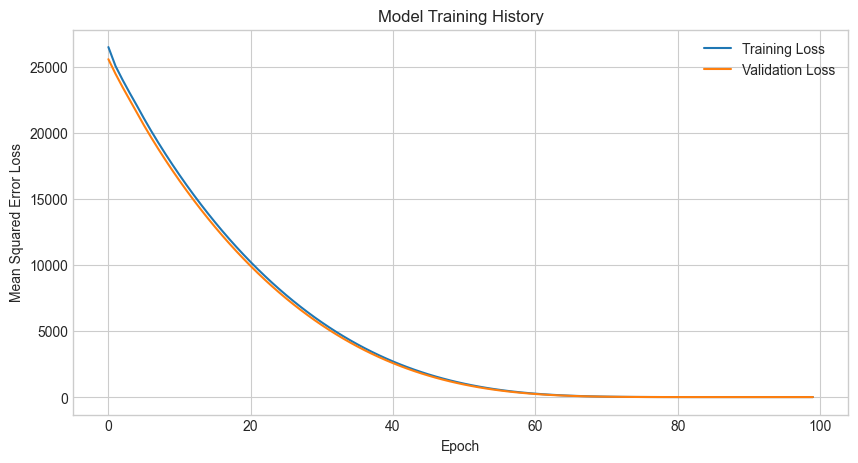

1/1 [==============================] - 0s 434ms/step

Explaining validation instance 0:
  Actual output: [176.77 165.4  160.82]
  Predicted output (using trained model): [174.57 167.01 158.43]
Computing gradients for Integrated Gradients...
Gradient computation finished in 0.79 seconds.
Integrated Gradients calculated. Shape: (50, 40)

Generating TFCM Visualization...


C:\Users\tamin\AppData\Local\Temp\ipykernel_18476\1311600013.py:427: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust layout to prevent title overlap


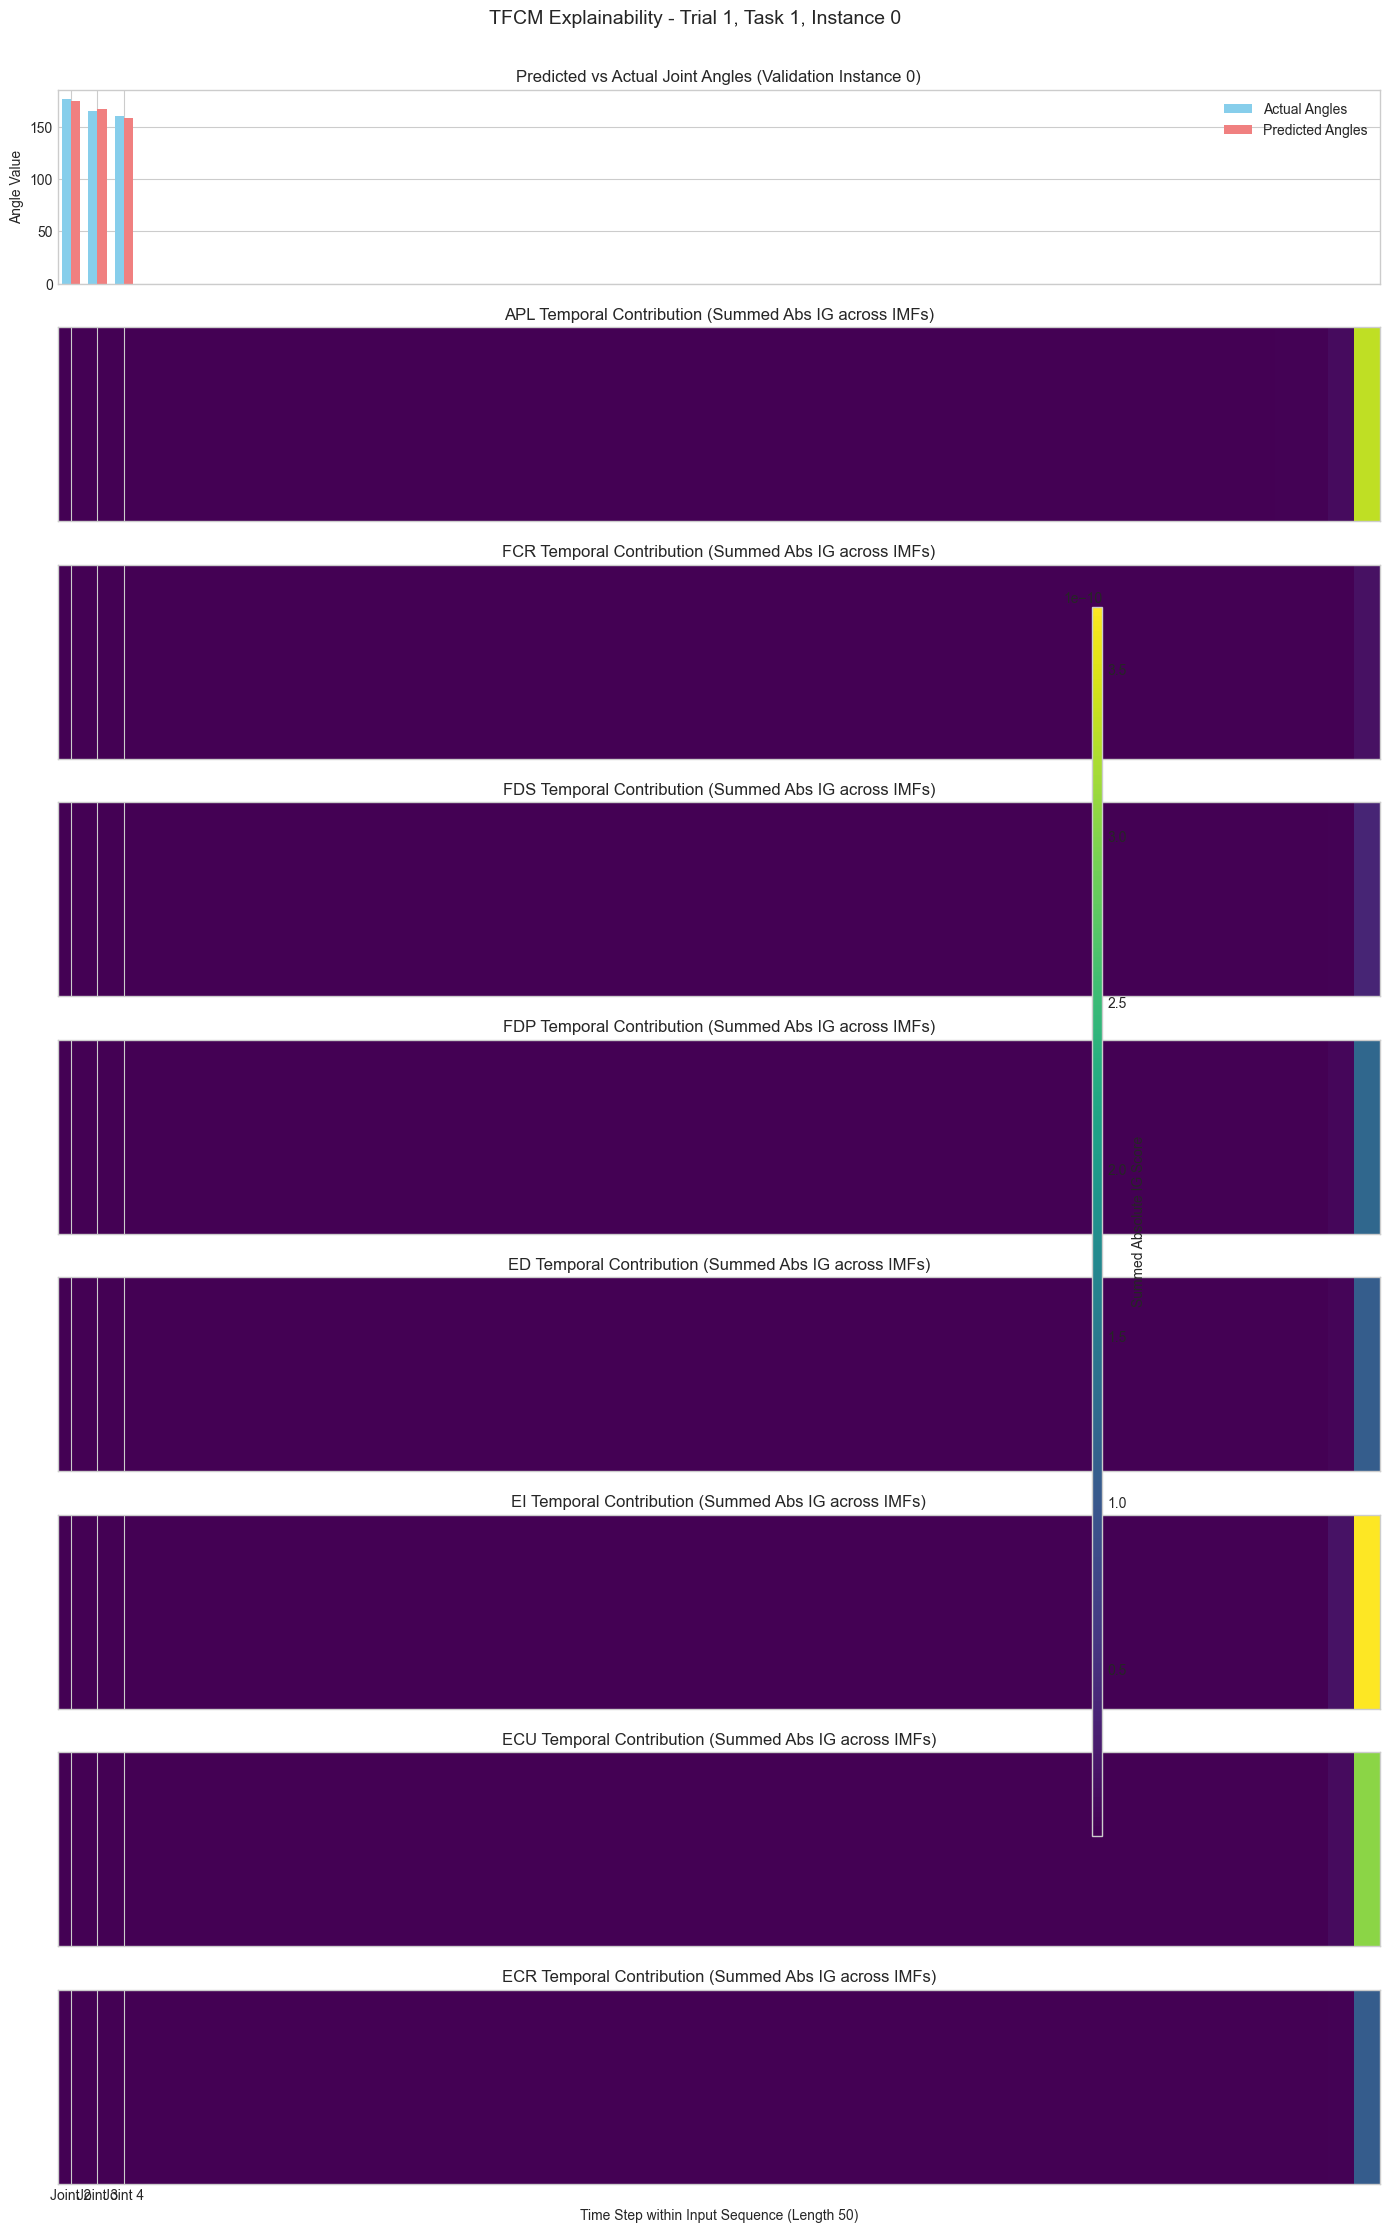

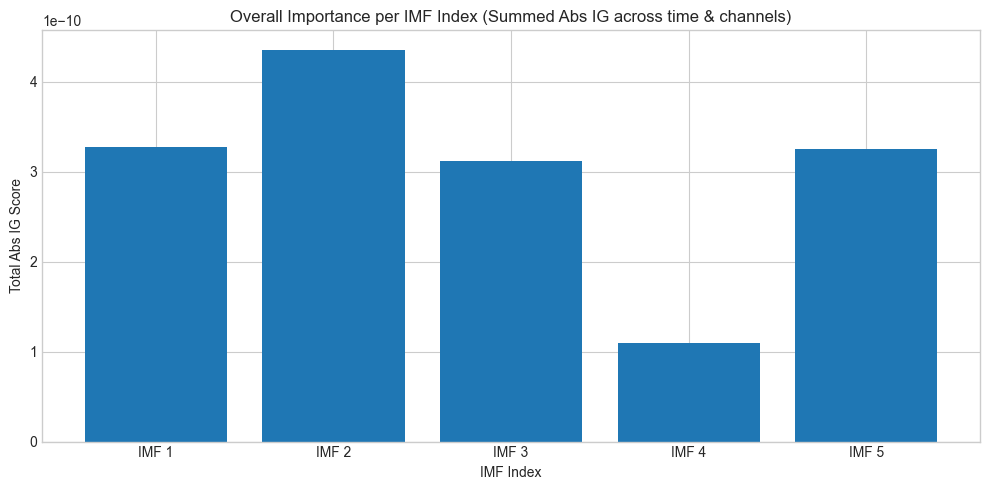


TFCM analysis structure complete.


In [17]:
# Required libraries
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PyEMD import EEMD  # Ensemble Empirical Mode Decomposition
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split # For splitting data
import time # To measure EMD time
import warnings # To suppress potential EMD warnings if needed

# Suppress specific warnings if they become noisy (optional)
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)


# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat' # <--- MAKE SURE THIS PATH IS CORRECT
TRIAL_IDX = 0  # Example: First trial (index 0)
TASK_IDX = 0   # Example: First task (index 0)
N_IMFS_EXTRACT = 5 # Max number of IMFs to extract per EMG channel (adjust as needed)
SEQUENCE_LENGTH = 50 # Example sequence length for LSTM input
TARGET_JOINT_INDICES = [2, 3, 4] # Example: Predict Index finger angles (Index 1, 2, 3) - Indices 2, 3, 4 in the 14-column data
TRAIN_VAL_SPLIT_RATIO = 0.2 # 20% of data for validation
RANDOM_STATE_SPLIT = 42 # For reproducible train/test splits
LSTM_EPOCHS = 100 # Number of training epochs (adjust based on convergence)
LSTM_BATCH_SIZE = 32 # Batch size for training

# --- 1. Load Data ---
try:
    mat_data = scipy.io.loadmat(MAT_FILE_PATH)
    print("MAT file loaded successfully.")
    # Accessing cell arrays requires careful indexing
    # Ensure variable names match EXACTLY those in the .mat file
    dsfilt_emg_cell = mat_data['dsfilt_emg']
    joint_angles_cell = mat_data['joint_angles']

    # Select data for the chosen trial and task
    emg_data = dsfilt_emg_cell[TRIAL_IDX, TASK_IDX]
    joint_angles_data = joint_angles_cell[TRIAL_IDX, TASK_IDX]

    # Select target joint angles based on configuration
    target_angles = joint_angles_data[:, TARGET_JOINT_INDICES]

    print(f"Selected EMG data shape: {emg_data.shape}") # Should be (e.g., 4000, 8)
    print(f"Selected Joint Angles shape: {joint_angles_data.shape}") # Should be (e.g., 4000, 14)
    print(f"Selected Target Angles shape: {target_angles.shape}") # Shape depends on TARGET_JOINT_INDICES

    # Basic data validation
    if not isinstance(emg_data, np.ndarray) or emg_data.ndim != 2:
        raise ValueError("EMG data for the selected trial/task is not a 2D numpy array.")
    if not isinstance(target_angles, np.ndarray) or target_angles.ndim != 2:
         raise ValueError("Target angle data for the selected trial/task is not a 2D numpy array.")
    if np.isnan(emg_data).any() or np.isinf(emg_data).any():
        print("Warning: NaN or Inf values found in EMG data. Consider imputation or cleaning.")
        # Handle NaNs if necessary, e.g., imputation
        emg_data = np.nan_to_num(emg_data)
    if np.isnan(target_angles).any() or np.isinf(target_angles).any():
        print("Warning: NaN or Inf values found in target angles. Consider imputation or cleaning.")
        # Handle NaNs if necessary
        target_angles = np.nan_to_num(target_angles)


except FileNotFoundError:
    print(f"Error: MAT file not found at {MAT_FILE_PATH}")
    exit()
except KeyError as e:
    print(f"Error: Variable {e} not found in the MAT file. Check variable names ('dsfilt_emg', 'joint_angles').")
    exit()
except IndexError:
     print(f"Error: TRIAL_IDX={TRIAL_IDX} or TASK_IDX={TASK_IDX} is out of bounds for the cell array dimensions.")
     exit()
except ValueError as e:
    print(f"Data loading/validation error: {e}")
    exit()
except Exception as e:
    print(f"An unexpected error occurred loading data: {e}")
    exit()

# --- 2. IMF Generation (EEMD) ---
n_emg_channels = emg_data.shape[1]
n_samples = emg_data.shape[0]
all_imfs_list = []

print(f"\nStarting EEMD for {n_emg_channels} EMG channels...")
start_time_emd = time.time()

# Initialize EEMD - parameters might need tuning based on signal characteristics
# S_number: std deviation of added noise, trials: number of ensemble trials
# Consider adjusting noise_width and trials based on your specific EMG data noise level
eemd = EEMD(trials=100, noise_width=0.1, S_number=4, max_imf=N_IMFS_EXTRACT)

for i in range(n_emg_channels):
    print(f"  Processing EMG channel {i+1}/{n_emg_channels}...")
    # Ensure data is float64 and C-contiguous, which PyEMD often expects
    channel_data = np.ascontiguousarray(emg_data[:, i], dtype=np.float64)

    try:
        # Perform EEMD.
        channel_imfs = eemd(channel_data, max_imf=N_IMFS_EXTRACT) # Pass max_imf here too

        # Pad with zeros if fewer IMFs are found than N_IMFS_EXTRACT
        # PyEMD typically returns (n_imfs, n_samples)
        num_found_imfs = channel_imfs.shape[0]
        if num_found_imfs < N_IMFS_EXTRACT:
            print(f"    Warning: Found only {num_found_imfs} IMFs for channel {i+1}. Padding with zeros.")
            padding = np.zeros((N_IMFS_EXTRACT - num_found_imfs, n_samples))
            channel_imfs = np.vstack((channel_imfs, padding))
        elif num_found_imfs > N_IMFS_EXTRACT:
             print(f"    Warning: Found {num_found_imfs} IMFs for channel {i+1}. Using top {N_IMFS_EXTRACT}.")
             channel_imfs = channel_imfs[:N_IMFS_EXTRACT, :] # Keep only top N_IMFS_EXTRACT

        all_imfs_list.append(channel_imfs)
        print(f"    Stored {channel_imfs.shape[0]} IMFs.")

    except Exception as e:
        print(f"    Error during EEMD for channel {i+1}: {e}")
        # Handle error appropriately, e.g., skip channel or fill with zeros
        all_imfs_list.append(np.zeros((N_IMFS_EXTRACT, n_samples)))


end_time_emd = time.time()
print(f"EEMD finished in {end_time_emd - start_time_emd:.2f} seconds.")

# Check if any IMFs were generated
if not all_imfs_list:
    print("Error: No IMFs were generated. Exiting.")
    exit()

# Combine IMFs into a single feature matrix
# We want shape (n_samples, n_features) where n_features = n_emg_channels * n_imfs_extracted
# Each element in all_imfs_list is (n_imfs_extracted, n_samples)
# Transpose each element to (n_samples, n_imfs_extracted) before stacking horizontally
try:
    imf_features = np.hstack([imfs.T for imfs in all_imfs_list])
    print(f"\nCombined IMF features shape: {imf_features.shape}")
    if np.isnan(imf_features).any() or np.isinf(imf_features).any():
        print("Warning: NaN or Inf values found in combined IMF features after EMD. Imputing with zeros.")
        # Impute NaNs/Infs that might arise from EMD issues or padding
        imf_features = np.nan_to_num(imf_features, nan=0.0, posinf=0.0, neginf=0.0)


except ValueError as e:
    print(f"Error combining IMFs: {e}. This might happen if EMD failed for some channels.")
    exit()


# --- 3. Data Preparation for Sequence Model ---
def create_sequences(input_data, output_data, sequence_length):
    """Creates sequences for LSTM input."""
    X, y = [], []
    # Ensure sufficient data length
    if len(input_data) <= sequence_length:
        print(f"Error: Data length ({len(input_data)}) is less than or equal to sequence length ({sequence_length}). Cannot create sequences.")
        return None, None
    for i in range(len(input_data) - sequence_length):
        X.append(input_data[i:(i + sequence_length)])
        # Predict the angle(s) at the end of the input sequence
        y.append(output_data[i + sequence_length -1])
    if not X: # Check if sequence creation failed
        print("Warning: No sequences were created. Check data length and sequence length.")
        return None, None
    return np.array(X), np.array(y)

# Create sequences
X_seq, y_seq = create_sequences(imf_features, target_angles, SEQUENCE_LENGTH)

if X_seq is None or y_seq is None:
    print("Exiting due to sequence creation error.")
    exit()

# Check for sufficient data after sequencing
if len(X_seq) < 100: # Increased threshold for minimal data for train/val split
     print(f"Warning: Only {len(X_seq)} sequences created. This might be insufficient for robust training/validation.")
     if len(X_seq) < 2: # Need at least 2 samples for train/test split
         print("Error: Insufficient data for train/validation split. Exiting.")
         exit()


print(f"\nSequence data shapes: X={X_seq.shape}, y={y_seq.shape}")

# --- 4. Model Definition (Example: LSTM) ---
n_features = imf_features.shape[1]  # Total number of IMF features
n_outputs = target_angles.shape[1] # Number of target joint angles

def build_lstm_model(sequence_length, n_features, n_outputs):
    """Builds a simple LSTM model."""
    model = Sequential([
        Input(shape=(sequence_length, n_features), name="Input_Sequence"),
        LSTM(64, return_sequences=True, name="LSTM_Layer_1"), # Intermediate LSTM layer
        LSTM(32, return_sequences=False, name="LSTM_Layer_2"), # Last LSTM outputs only final step
        Dense(n_outputs, name="Output_Dense") # Output layer for joint angles
    ], name="EMG_to_Angle_LSTM")
    model.compile(optimizer='adam', loss='mse') # Mean Squared Error is common for regression
    return model

# Ensure we have sequences before building model
if X_seq is not None and X_seq.shape[0] > 0:
    model = build_lstm_model(SEQUENCE_LENGTH, n_features, n_outputs)
    model.summary()
else:
    print("Skipping model building as no sequence data is available.")
    exit()


# --- 5. Model Training ---
print("\nStarting model training...")
# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y_seq,
    test_size=TRAIN_VAL_SPLIT_RATIO,
    random_state=RANDOM_STATE_SPLIT,
    shuffle=True # Shuffle data before splitting (usually good practice)
)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Validation data shape: X={X_val.shape}, y={y_val.shape}")

# Train the model
start_time_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs=LSTM_EPOCHS,
    batch_size=LSTM_BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1 # Set to 1 to see progress per epoch, 2 for less output, 0 for silent
)
end_time_train = time.time()
print(f"Model training finished in {end_time_train - start_time_train:.2f} seconds.")

# Optional: Plot training history (loss) - UNCOMMENTED
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True)
plt.show()

# **IMPORTANT**: Alternatively, load a pre-trained model if available
# model = tf.keras.models.load_model('my_trained_lstm_model.h5')
# print("Loaded pre-trained model instead of training.")

# --- 6. Explainability (TFCM Core - Integrated Gradients Example) ---
# Select a specific sequence instance to explain from the *validation* set
# Ensure the index is valid for the validation sequences
if len(X_val) > 0:
    instance_index_to_explain = 0 # Explain the first validation sequence
else:
    print("Error: Validation set is empty. Cannot select instance for explanation.")
    # Fallback: use training data instance if validation is empty (not ideal)
    if len(X_train) > 0:
        print("Warning: Using first training instance for explanation as validation set is empty.")
        instance_index_to_explain = 0
        input_instance = X_train[instance_index_to_explain:instance_index_to_explain+1]
        actual_output = y_train[instance_index_to_explain]
    else:
        print("Error: No data available for explanation. Exiting.")
        exit()

# If validation set is available, use it
if len(X_val) > 0:
   input_instance = X_val[instance_index_to_explain:instance_index_to_explain+1] # Keep batch dimension (shape: 1, seq_len, n_features)
   actual_output = y_val[instance_index_to_explain]


# Generate a prediction for this instance using the *trained* model
# Wrap prediction in try-except block
try:
    predicted_output = model.predict(input_instance)[0] # Get prediction for the single instance
    print(f"\nExplaining validation instance {instance_index_to_explain}:")
    print(f"  Actual output: {np.round(actual_output, 2)}")
    print(f"  Predicted output (using trained model): {np.round(predicted_output, 2)}")
except Exception as e:
    print(f"Error during model prediction: {e}")
    exit()

# --- Integrated Gradients Implementation Concept ---
# IG requires a baseline (e.g., zero input)
baseline_instance = np.zeros_like(input_instance) # Shape: (1, seq_len, n_features)
m_steps = 50 # Number of steps for the integration approximation (more steps = smoother but slower)
alphas = tf.linspace(start=0.0, stop=1.0, num=m_steps+1) # Interpolation steps: [0.0, ..., 1.0]

# Function to compute gradients for a given input batch
@tf.function # Decorate for performance
def compute_gradients(input_batch):
    """Computes gradients of the model output sum w.r.t the input batch."""
    with tf.GradientTape() as tape:
        tape.watch(input_batch) # Ensure tape watches the input
        predictions = model(input_batch) # Get model output for the batch
        # Sum gradients across output dimensions for an overall attribution per input feature.
        # Alternatively, could compute gradients for EACH output neuron separately.
        target_output_sum = tf.reduce_sum(predictions, axis=-1) # Sum across output joints for each item in batch
    return tape.gradient(target_output_sum, input_batch) # Get gradients w.r.t input_batch

# Generate interpolated inputs batch
# Reshape alphas for broadcasting: (m_steps+1, 1, 1, 1)
alphas_reshaped = tf.reshape(alphas, (m_steps + 1, 1, 1, 1))
# Calculate interpolated inputs using broadcasting
interpolated_inputs_batch = baseline_instance + alphas_reshaped * (input_instance - baseline_instance)
# Result shape: (m_steps+1, 1, seq_len, n_features) - extra batch dim of 1

# Remove the extra batch dimension for processing if compute_gradients expects (batch, seq, feat)
interpolated_inputs_batch_squeezed = tf.squeeze(interpolated_inputs_batch, axis=1)
# Result shape: (m_steps+1, seq_len, n_features) - this is now our batch for gradient computation

# Compute gradients for the batch of interpolated inputs
print("Computing gradients for Integrated Gradients...")
start_time_ig = time.time()
try:
    # Ensure the model is callable within tf.function context
    gradients_batch = compute_gradients(tf.constant(interpolated_inputs_batch_squeezed.numpy(), dtype=tf.float32)) # Ensure tensor type
except Exception as e:
    print(f"Error computing gradients: {e}")
    # Common issues: model structure mismatch, NaN in inputs/weights, tf.function tracing errors
    exit()

end_time_ig = time.time()
print(f"Gradient computation finished in {end_time_ig - start_time_ig:.2f} seconds.")

# Check if gradients computation returned None (can happen with graph issues)
if gradients_batch is None:
    print("Error: Gradient computation returned None. Check model structure and inputs.")
    exit()

# Average gradients using trapezoidal rule for better approximation (optional)
# Simple mean: avg_gradients = tf.reduce_mean(gradients_batch, axis=0)
# Trapezoidal rule:
grads = gradients_batch.numpy()
grads = (grads[:-1] + grads[1:]) / 2.0 # Average adjacent pairs
avg_gradients = np.mean(grads, axis=0) # Average over the m_steps intervals

# Calculate Integrated Gradients: (input - baseline) * avg_gradients
# Since baseline is zero, it's just input * avg_gradients
# input_instance shape is (1, seq_len, n_features), avg_gradients is (seq_len, n_features)
integrated_gradients = input_instance[0] * avg_gradients # Shape: (seq_len, n_features)

print(f"Integrated Gradients calculated. Shape: {integrated_gradients.shape}")

# Handle potential NaNs in IG scores (less likely with trained model but possible)
if np.isnan(integrated_gradients).any():
    print("Warning: NaN values found in Integrated Gradients scores. Attributions might be unreliable. Check model weights/gradients.")
    # Option: Replace NaNs with zero for visualization purposes
    integrated_gradients = np.nan_to_num(integrated_gradients, nan=0.0)

# Reshape IG scores back to (sequence_length, n_emg_channels, n_imfs_extracted) for easier interpretation
try:
    ig_scores_reshaped = integrated_gradients.reshape(SEQUENCE_LENGTH, n_emg_channels, N_IMFS_EXTRACT)
except ValueError as e:
    print(f"Error reshaping IG scores: {e}. Check if n_features ({integrated_gradients.shape[1]}) matches n_emg_channels*N_IMFS_EXTRACT ({n_emg_channels*N_IMFS_EXTRACT}).")
    exit()


# Sum absolute IG scores over IMFs for each channel to get channel importance over time
channel_temporal_importance = np.sum(np.abs(ig_scores_reshaped), axis=2) # Sum abs contributions -> (seq_len, n_emg_channels)

# Sum absolute IG scores over time and channels for each IMF index -> Feature importance
imf_overall_importance = np.sum(np.abs(ig_scores_reshaped), axis=(0, 1)) # Sum abs contributions -> (n_imfs_extracted,)


# --- 7. Visualization (TFCM Heatmap) ---
print("\nGenerating TFCM Visualization...")

# Use a style that supports grid lines well
plt.style.use('seaborn-v0_8-whitegrid')
# Create figure and axes
# Increase height per subplot for better readability
fig, axes = plt.subplots(n_emg_channels + 1, 1, figsize=(14, 2.5 * (n_emg_channels + 1)), sharex=True)

# Plot Predicted vs Actual Angles (for selected joints)
time_axis_pred = np.arange(n_outputs) # X-axis for the single predicted point's outputs
# Use bar chart for comparing the multi-output prediction vs actual
bar_width = 0.35
x_indices = np.arange(n_outputs)
rects1 = axes[0].bar(x_indices - bar_width/2, actual_output, bar_width, label='Actual Angles', color='skyblue')
rects2 = axes[0].bar(x_indices + bar_width/2, predicted_output, bar_width, label='Predicted Angles', color='lightcoral')

axes[0].set_title(f'Predicted vs Actual Joint Angles (Validation Instance {instance_index_to_explain})')
axes[0].set_ylabel('Angle Value')
axes[0].set_xticks(x_indices)
# Use user-provided or generic joint names if available
joint_names = [f'Joint {j}' for j in TARGET_JOINT_INDICES]
axes[0].set_xticklabels(joint_names, rotation=45, ha="right")
axes[0].legend()
axes[0].grid(True, axis='y') # Grid lines only on y-axis for bar chart

# Plot contribution heatmaps for each EMG channel using imshow
time_axis_seq = np.arange(SEQUENCE_LENGTH)
# Find global min/max of absolute importance for consistent color scaling across channels
abs_channel_importance = np.abs(channel_temporal_importance) # Use absolute value for magnitude visualization
vmin = np.min(abs_channel_importance)
vmax = np.max(abs_channel_importance)
# Add a small epsilon if min and max are the same to avoid division by zero in color mapping
if vmin == vmax:
    vmax += 1e-6

# User-provided muscle names
muscle_names = ["APL", "FCR", "FDS", "FDP", "ED", "EI", "ECU", "ECR"]

for i in range(n_emg_channels):
    ax = axes[i+1]
    # Importance of channel i over time (absolute value)
    temporal_importance = abs_channel_importance[:, i] # Shape: (seq_len,)

    # Reshape for imshow: (1, seq_len)
    heatmap_data = temporal_importance[np.newaxis, :]

    # Display heatmap
    im = ax.imshow(heatmap_data, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax,
                   extent=[time_axis_seq[0]-0.5, time_axis_seq[-1]+0.5, -0.5, 0.5]) # Adjust extent for centering

    # Use muscle names if available and match channel count
    channel_label = muscle_names[i] if i < len(muscle_names) else f'Channel {i+1}'
    ax.set_title(f'{channel_label} Temporal Contribution (Summed Abs IG across IMFs)')
    ax.set_yticks([]) # Hide Y axis ticks for heatmap row

# Add a single colorbar for all heatmaps
# Adjust fraction and pad as needed based on figure size
fig.colorbar(im, ax=axes[1:].tolist(), shrink=0.8, aspect=15*n_emg_channels, pad=0.02, label='Summed Absolute IG Score')

axes[-1].set_xlabel(f'Time Step within Input Sequence (Length {SEQUENCE_LENGTH})')
plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust layout to prevent title overlap
plt.suptitle(f'TFCM Explainability - Trial {TRIAL_IDX+1}, Task {TASK_IDX+1}, Instance {instance_index_to_explain}', fontsize=14, y=0.99)
plt.show()

# Optional: Plot overall IMF importance - UNCOMMENTED
plt.figure(figsize=(10, 5))
imf_labels = [f'IMF {j+1}' for j in range(N_IMFS_EXTRACT)]
plt.bar(imf_labels, imf_overall_importance)
plt.title('Overall Importance per IMF Index (Summed Abs IG across time & channels)')
plt.ylabel('Total Abs IG Score')
plt.xlabel('IMF Index')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


print("\nTFCM analysis structure complete.")


In [14]:
pip install EMD-signal

  Using cached EMD_signal-1.6.4-py3-none-any.whl.metadata (8.9 kB)
Using cached EMD_signal-1.6.4-py3-none-any.whl (75 kB)
Note: you may need to restart the kernel to use updated packages.
